<a href="https://colab.research.google.com/github/IamSherlockeddd/FUZZ2025/blob/main/SISAP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FTH requirements :

In [ ]:
!pip install scikit-fuzzy

import networkx as nx
import pandas as pd
import multiprocessing as mp
import matplotlib.pyplot as plt
from numba import prange
from typing import List
import skfuzzy as fuzz
from scipy import signal
import numpy as np
from functools import lru_cache
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 31.9 MB/s eta 0:00:00


In [ ]:
# Get the ontology (activities)

!wget https://gist.githubusercontent.com/MerakchiHibaa/a8c2c2539e9def873f8591cc642377e5/raw/b2007792c9b2343f81506319b78b3f9139244b10/sisap.text -q --show-progress

sisap.text          100%[===================>]     117  --.-KB/s    in 0s      


In [ ]:
path_onto = "sisap.text"

ontology_emd = nx.read_adjlist(path_onto, create_using=nx.DiGraph) # creates a directed graph (DiGraph) representation of the ontology data.



In [ ]:
# Wu-palmer similarity
@lru_cache(maxsize=100000)
def wu_palmer(x: str, y: str, path: str, rootnode="All") -> float:
    ontologie = nx.read_adjlist(path, create_using=nx.DiGraph)
    return (2.0 * nx.shortest_path_length(ontologie, rootnode, nx.lowest_common_ancestor(ontologie, x, y))) / (
            nx.shortest_path_length(ontologie, rootnode, x) + nx.shortest_path_length(ontologie, rootnode, y))



# Define the used similarity
def sim(x: str, y: str) -> float:
    return wu_palmer(x, y, path_onto)



In [ ]:
from typing import List, TypeVar

T = TypeVar('T') # defines a type variable and allows the class to work with generic types.
# https://dev.to/decorator_factory/typevars-explained-hmo


class Temporal_seq:
    def __init__(self, acts: List[T], times: List[float]) -> None:
        self.acts = acts
        self.times = times
        # acts: A list of elements of type T. The type variable T allows the list to contain elements of any type.
        # times: A list of floating-point numbers representing the corresponding times for each activity.

In [ ]:
class Edit_FTH:# To define the edit operation
    def __init__(self, x: str, delta: float, t_edit: float, S_i: Temporal_seq):
        self.x = x # the activity
        self.delta = delta # the duration
        self.t_edit = t_edit # the starting point
        self.S_i = S_i # the sequence


In [ ]:
def sim_fth_e(e: Edit_FTH, t: float) -> float: #  for t in I (starts with 0)
    """
    :param e:     Edit operation
    :param t:     Time t
    :return:      Similarity over the sequence at time t
    """
    for i in prange(len(e.S_i.times)):# Iterate through the times in the sequence 'e.S_i'
    # every i is an index for a duration (starts with 0)
        if np.sum(e.S_i.times[:i]) <= t < np.sum(e.S_i.times[:i + 1]): # # Check if 't' falls within the time interval of the current activity in the sequence
            return sim(e.S_i.acts[i], e.x) # If 't' is within the interval, return the similarity between the current activity and 'e.x'
    return 0

## FTH :

In [ ]:
def cost_gamma_fth(e: Edit_FTH, interval_step = 1, time_window = 120) -> float:
  I = np.arange(0, np.sum(e.S_i.times)  , interval_step) # the duration divided by the interval step
  mu = fuzz.trapmf(I, [e.t_edit - time_window, e.t_edit, e.t_edit + e.delta, # the context function
                       e.t_edit + e.delta + time_window])
  sim_fun = [sim_fth_e(e, t) for t in I] # the similarity measure, t starts with 0
  sim_context = [mu[i] * sim_fun[i] for i in range(len(I))] # the similarity multiplied by the context function
  tab_gate = np.arange(0, e.delta, interval_step)
  gate = fuzz.trapmf(tab_gate, [0, 0, e.delta, e.delta])
  convo = signal.convolve(sim_context, gate, mode='same') / (e.delta / interval_step) # calculates the convolution weighted by the duration divided by the interval step
  return 1 - np.max(convo) # returns the cost (between 0 and 1)

def cost_delta_fth(e: Edit_FTH, interval_step = 1, time_window = 120) -> float:
  return e.delta * cost_gamma_fth(e, interval_step, time_window) # returns the weighted cost (cost multiplied by the duration of the new activity )

# The function that calculates the one-sided distance between two trajectories
def one_sided_dist_fth(S1: Temporal_seq, S2: Temporal_seq, f = cost_delta_fth, interval_step = 1, time_window = 120) -> float:
  sum = 0

  for i in prange(len(S1.acts)): # starts from 0
    e = Edit_FTH(S1.acts[i], S1.times[i], np.sum(S1.times[:i]), S2) # np.sum(S1.times[:i]) calculates the cumulative time spent on actions prior to the current action at index i (to get the beginning of the activity)
    sum += f(e, interval_step, time_window) # f is the used cost function (delta or gamma function)
  return sum # sum represents the sum of maximal costs necessary for all the edit operations


In [ ]:
# Calculation of the FTH distance
def dist_fth(S1: Temporal_seq, S2: Temporal_seq, f = cost_delta_fth, interval_step = 1, time_window = 120, agg = max)-> float:
  return agg(one_sided_dist_fth(S1, S2, f, interval_step, time_window), # returns the maximal one-sided cost to get from S1 to S2 or from S2 to S1
             one_sided_dist_fth(S2, S1, f, interval_step, time_window))


In [ ]:
# Fuction that calculates the t-length of a given sequence
def sum_duration(sequence: Temporal_seq) -> float: # gives the sum of durations for a sequence
    return sum(sequence.times)

In [ ]:
# Fuction that decodes the activities to be used when we show the results
def decode_activities(acts: List[str]) -> List[str]:
    activity_mapping = {
        "1": "Walk",
        "2": "Bike",
        "3": "Car",
        "4": "Pts",
        "5": "Leisure",
        "6": "Shopping",
        "7": "Work",
        "8": "Studying",
        "9": "Missing",

    }
    decoded_activities = [activity_mapping[act] for act in acts]
    return decoded_activities

# Example
s_h = Temporal_seq(['1', '4', '5'], [30, 5, 12])
decoded_activities = decode_activities(s_h.acts)
print(decoded_activities)

['Walk', 'Pts', 'Leisure']


### Relative FTH

In [ ]:
# DEFINE A RELATIVE TEMPORAL SEQUENCE FROM A TEMPORAL SEQUENCE T
import copy
def relative_temporal_seq(T :Temporal_seq ) -> Temporal_seq:
  """
  T :Temporal_seq
  Returns a relative temporal sequence
  """
  T_ = copy.deepcopy(T)
  T_max_seq = sum_duration(T_)
  relative_times = [time / T_max_seq * 100 for time in T_.times]
  return Temporal_seq(T_.acts, relative_times)

In [ ]:
# DEFINE A ROUNDED RELATIVE TEMPORAL SEQUENCE FROM A TEMPORAL SEQUENCE T (BY ROUNDING THE RELATIVE DURATIONS)
def rounded_relative_temporal_seq(T: Temporal_seq) -> Temporal_seq:
    T_ = copy.deepcopy(T)
    T_max_seq = sum(T_.times)
    relative_times = [time / T_max_seq * 1000 for time in T_.times]
    integer_parts = [int(time) for time in relative_times] # Truncate to integer part
    remainders = [time - int(time) for time in relative_times] # Calculate remainders
    # Rank remainders in decreasing order
    ranked_remainders = sorted([(i,integer_parts[i], remainders[i]) for i in range(len(integer_parts))], key=lambda x: x[2], reverse=True)
    sum_integers = sum(integer_parts)
    index = 0

    # While the sum of integers is less than 1000, add one to the integer with the next biggest integer
    while sum_integers < 1000:
        index %= len(ranked_remainders) # Wrap around if we reach the end of the ranked remainders list
        i, integer_part, _ = ranked_remainders[index] # Get the index of the next biggest remainder
        integer_parts[i] += 1 # Add one to the integer part
        sum_integers += 1 # Increment the sum of remainders
        index += 1 # Move to the next remainder

    return Temporal_seq(T_.acts, integer_parts)



In [ ]:
p_test = Temporal_seq(['1', '2', '3'],[10, 20, 30])
print(sum_duration(p_test))
print(rounded_relative_temporal_seq(p_test).times)

60
[167, 333, 500]


In [ ]:
# FUNCTION THAT CALCULATES THE FTH_DELTA DISTANCE BETWEEN TWO RELATIVE SEQUENCES AND OUTPUTS THE RESULTS

def FTH_relative_fuzz(sequence, pattern, f=cost_delta_fth, interval_step = 1, time_window = 120):
    # Compute the relative temporal sequence for the pattern and the sequence
    patt = copy.deepcopy(pattern)
    relative_pattern = rounded_relative_temporal_seq(patt)
    # print('relative pattern ', relative_pattern.acts, relative_pattern.times)

    seq = copy.deepcopy(sequence)
    relative_sequence = rounded_relative_temporal_seq(seq)
    # print('relative sequence ', relative_sequence.acts, relative_sequence.times)


    # relative parameters
    relative_interval_step = math.floor(interval_step / sum_duration(patt) * 1000)
    # print('relative_interval_step ', relative_interval_step)
    relative_time_window = math.floor(time_window / sum_duration(patt) * 1000)
    # print('relative_time_window ' , relative_time_window)

    # Calculate the distance
    distance = dist_fth(relative_pattern, relative_sequence, f=f, interval_step=relative_interval_step, time_window=relative_time_window, agg=max) / 1000

    # Decode and display the result
    decoded_sequence = decode_activities(seq.acts)
    print("Distance:", distance, " - Sequence:", decoded_sequence, seq.times)


In [ ]:
# From FTH_Delta to Sim_Delta
def similarity_fth(fth_distance):
    """
    Computes the similarity score based on FTH distance

    Parameters:
        fth_distance (float): The FTH distance between two sequences.
    Returns:
        float: The similarity score.
    """

    return 1 - fth_distance

# Example
fth_dist = 0.4


similarity = similarity_fth(fth_dist)
print(f"FTH Similarity: {similarity}")


FTH Similarity: 0.6


In [ ]:
def IC(lt_Sa, lt_Sb, l_RFTH):
    """
    Computes the t-length comparability index between two sequences Sa and Sb
    with parameter l_RFTH.

    Parameters:
    - lt_Sa, lt_Sb: t_lengths of compared sequences Sa and Sb, respectively.
    - l_RFTH: half of the fuzzy function support.

    Returns:
    - float: t_length comparability score between 0 and 1
    """

    diff = abs(lt_Sa - lt_Sb)

    if diff >= l_RFTH:
        return 0.0
    else:
        return 1 - (diff / l_RFTH)

# Example usage

l_RFTH = 3


In [ ]:
def calculate_product(a, b):
    """
    Calculates the product of two values.

    Args:
        a (float): First value.
        b (float): Second value.

    Returns:
        float: The product of the two values.
    """
    return a * b


def calculate_minimum(a, b):
    """
    Calculates the minimum of two values.

    Args:
        a (float): First value.
        b (float): Second value.

    Returns:
        float: The minimum of the two values.
    """
    return min(a, b)


def calculate_lukasiewicz(a, b):
    """
    Calculates the Lukasiewicz T-Norm of two values.

    Args:
        a (float): First value.
        b (float): Second value.

    Returns:
        float: The Lukasiewicz T-Norm, defined as max(0, a + b - 1).
    """
    return max(0, a + b - 1)



value1 = 0.8
value2 = 0.6

# Product calculation
product_result = calculate_product(value1, value2)
print(f"Product of {value1} and {value2}: {product_result}")  # Output: 0.48

# Minimum calculation
minimum_result = calculate_minimum(value1, value2)
print(f"Minimum of {value1} and {value2}: {minimum_result}")  # Output: 0.6

# Lukasiewicz T-Norm calculation
lukasiewicz_result = calculate_lukasiewicz(value1, value2)
print(f"Lukasiewicz T-Norm of {value1} and {value2}: {lukasiewicz_result}")  # Output: 0.4


Product of 0.8 and 0.6: 0.48
Minimum of 0.8 and 0.6: 0.6
Lukasiewicz T-Norm of 0.8 and 0.6: 0.3999999999999999


In [ ]:
# V2 : FUNCTION THAT CALCULATES THE FTH_DELTA DISTANCE BETWEEN TWO RELATIVE SEQUENCES

def FTH_relative_fuzz_fun(sequence, pattern, f=cost_delta_fth, interval_step=1, time_window=240):
    # Compute the relative temporal sequence for the pattern and the sequence
    patt = copy.deepcopy(pattern)
    relative_pattern = rounded_relative_temporal_seq(patt)

    # print('relative pattern ', relative_pattern.acts, relative_pattern.times)

    seq = copy.deepcopy(sequence)
    relative_sequence = rounded_relative_temporal_seq(seq)
    # print('relative sequence ', relative_sequence.acts, relative_sequence.times)

    # relative parameters
    relative_interval_step = math.floor(interval_step / sum_duration(patt) * 1000)
    # print('relative_interval_step ', relative_interval_step)
    relative_time_window = math.floor(time_window / sum_duration(patt) * 1000)
    # print('relative_time_window ' , relative_time_window)


    # Calculate the distance
    distance_fth = dist_fth(relative_pattern, relative_sequence, f=f, interval_step=1, time_window=relative_time_window, agg=max)
    distance_FTH_normalized = distance_fth / 1000
    # print('distance_fth ' , distance_fth)
    # print('distance_FTH_normalized = distance_fth / 1000 ', distance_FTH_normalized)

    return distance_FTH_normalized


## CED

In [ ]:
from enum import Enum
from typing import List, TypeVar
# To be generic
T = TypeVar('T')
class Edit(Enum): # the edit operations
  MOD = 1
  ADD = 2
  DEL = 3

class Cxt_edit: # A contextual edit operation e is a 4-uplet ( the operation, the element, the position, the sequence)
    def __init__(self, op: Edit, x: str, i_edit: int, S_i: List[str]):
        """
        :param op:      Edit operation (MOD, ADD, DEL)
        :param x:       Edited symbol
        :param k_edit:  Edited index in the sequence seq_i
        :param seq_i:   Edited sequence
        """
        self.op = op
        self.x = x
        self.i_edit = i_edit - 1 # the index
        self.S_i = S_i
        self.text = f'({op}, {x}, {i_edit})'

S1 = ['1', '7', '1', '11', '2', '5', '2', '9']
e = Cxt_edit(Edit.MOD, '1', 4, S1)
print(e.text)

(Edit.MOD, 1, 4)


In [ ]:
def temporal_vec(e: Cxt_edit, beta : int) -> List[float]: # Creates a trapezoidal membership function (mu).
    # This function generates fuzzy values based on the range of indices determined by the length of e.S_i.
    mu = fuzz.trapmf(np.arange(0, np.sum(len(e.S_i)+1)),
                     [e.i_edit - beta, e.i_edit, e.i_edit, e.i_edit + beta])
    if e.op == Edit.MOD:
        return mu[:-1] # Returns the membership function mu excluding the last element ( because mu returns an additional element at the end of the array )

    if e.op == Edit.ADD:
        return([mu[i] if i < e.i_edit else
                (mu[e.i_edit - 1] if i == e.i_edit else mu[i + 1])
                for i in range(len(e.S_i))])
        return [mu[i] if i < e.i_edit else
                (mu[e.i_edit - 1] if i == e.i_edit else mu[i + 1])
                for i in range(len(e.S_i))]
    else:
        return [mu[i] if i != e.i_edit else 0 for i in range(len(e.S_i))]
nu = temporal_vec(e, 4) # returns the valuses of the context function.
print(nu)

[0.25 0.5  0.75 1.   0.75 0.5  0.25 0.  ]


In [ ]:
def gamma_cost(e: Cxt_edit) -> float: # calculates the cost
    nu = temporal_vec(e, 3) # was 4
    ctx_vector = [sim(e.S_i[k], e.x) * nu[k] for k in range(len(e.S_i))]
    return 1 - max(ctx_vector)

In [ ]:
def one_sided_ced(S1: List[str], S2: List[str]) -> float: # calculates the one-sided CED between two trajectories S1 and S2
    dist = np.zeros((len(S1) + 1, len(S2) + 1)) # Create a matrix 'dist' filled with zeros of size (len(S1) + 1) x (len(S2) + 1)

    # Loop through indices i and j using prange (parallel range) from 0 to len(S1) and len(S2) respectively
    for i in prange(len(S1) + 1):
        for j in prange(len(S2) + 1):
            # For indices i or j equal to 0, assign the value of the cumulative edit distance (CED)
            if i == 0 or j == 0:
                dist[i, j] = j + i
            else: # Computes the cost for edit operations (modification, deletion, addition) using gamma_cost based on context edits.
                op_mod = Cxt_edit(Edit.MOD, S2[j-1], i, S1)
                op_del = Cxt_edit(Edit.DEL, S1[i-1], i, S2) # check this (S1)
                op_add = Cxt_edit(Edit.ADD, S2[j-1], i, S1)

                cost_mod = gamma_cost(op_mod)
                cost_del = gamma_cost(op_del)
                cost_add = gamma_cost(op_add)



                dist[i, j] = round(min(dist[i - 1, j-1] + cost_mod,
                                       dist[i - 1, j] + cost_del,
                                       dist[i, j - 1] + cost_add), 2)
    return dist[len(S1), len(S2)]

In [ ]:
def ced(S1: List[str], S2: List[str]) -> float: # CED is equal to the maximal value between the two one-sided-CEDs
    return max(one_sided_ced(S1, S2), one_sided_ced(S2, S1))

In [ ]:
def edit_dist(seq1, seq2): # traditional edit distance
    n =  len(seq1)
    p = len(seq2)
    dist = np.zeros((n + 1, p + 1))
    for i in range(n + 1):
        for j in range(p + 1):
            if i == 0 or j == 0:
                dist[i, j] = j + i
            else:
                cost = 1 - sim(seq1[i-1], seq2[j-1])
                #cost = 0 if seq1[i-1] == seq2[j-1] else 1
                dist[i, j] = round(min(dist[i - 1, j-1] + cost,
                                       dist[i - 1, j] + 1,
                                       dist[i, j - 1] + 1), 2)
    return dist[n, p]

## CED WITH TIME STEPS

In [ ]:
import math


# to_discrete skips the element if its duration is smaller than the step
def to_discrete(S_i: Temporal_seq, unit_of_time: float) -> List[str]:
  return [S_i.acts[k] for k in range(len(S_i.acts)) for j in range(int(S_i.times[k] / unit_of_time))]

# ============================================================
# TEMPORAL CED EXTENSION
# ============================================================

def find_common_step(times1: List[float], times2: List[float],
                     strategy: str = "gcd") -> float:
    all_times = times1 + times2
    if strategy == "gcd":
        int_times = [max(1, round(t)) for t in all_times]
        step = int_times[0]
        for t in int_times[1:]:
            step = math.gcd(step, t)
        return float(step)
    elif strategy == "min":
        return float(min(all_times))
    elif strategy == "mean":
        return float(np.mean(all_times))
    else:
        raise ValueError(f"Unknown strategy '{strategy}'. Use 'gcd', 'min', or 'mean'.")


def discretize_temporal_seq(seq: Temporal_seq, step: float) -> List[str]:
    """
    Expand a Temporal_seq into a flat activity list by repeating each
    activity round(duration / step) times.

    Example (step=5):
        acts  = ["4", "2", "1"]   (Work, Walk, Bike)
        times = [10,   5,  30]
        out   = ["4","4","2","1","1","1","1","1","1"]
    """
    # Removed decode_activities here to ensure numerical codes are used for similarity calculation
    flat: List[str] = []
    for act, dur in zip(seq.acts, seq.times):
        reps = max(1, round(dur / step))
        flat.extend([act] * reps)
    return flat


def temporal_ced(seq1: Temporal_seq, seq2: Temporal_seq,
                 strategy: str = "gcd",
                 custom_step: float = None,
                 verbose: bool = True, discretization_method = discretize_temporal_seq) -> float:
    step = custom_step if custom_step is not None \
           else find_common_step(seq1.times, seq2.times, strategy)

    flat1 = discretization_method(seq1, step)
    flat2 = discretization_method(seq2, step)

    if verbose:
        print(f"Step           : {step}")
        print(f"S1 discretized : {decode_activities(flat1)}  (len={len(flat1)})") # Decode for printing only
        print(f"S2 discretized : {decode_activities(flat2)}  (len={len(flat2)})") # Decode for printing only

    score = ced(flat1, flat2)   # your existing ced() — unchanged

    if verbose:
        print(f"Temporal CED   : {score:.4f}\n")

    return score


def temporal_edit_dist(seq1: Temporal_seq, seq2: Temporal_seq,
                       strategy: str = "gcd",
                       custom_step: float = None, discretization_method=discretize_temporal_seq) -> float:
    """Same pipeline but using the standard edit_dist as baseline."""
    step = custom_step if custom_step is not None \
           else find_common_step(seq1.times, seq2.times, strategy)
    flat1 = discretization_method(seq1, step)
    flat2 = discretization_method(seq2, step)
    return edit_dist(flat1, flat2)
# DEMO




## FTH_TRUNC

In [ ]:
from typing import List, TypeVar, Tuple, Optional

# Helper: total duration of a temporal sequence

def duration(S: Temporal_seq) -> float:
    """
    The 'length' of a temporal sequence = sum of all activity durations.
    times[i] is the duration of acts[i].
    """
    return sum(S.times)


In [ ]:
# Helper: extract the sub-sequence of S_long that starts at offset tau
#         and covers exactly `target_duration` worth of time.
#
#  This is the 'core' window  S'_max(tau)  used in the paper.

def extract_window(S_long: Temporal_seq, tau: float, target_duration: float) -> Temporal_seq:
    """
    Extract the sub-sequence of S_long whose time span is
    [tau, tau + target_duration].

    Activities that fall partially inside the window are clipped so that
    the returned sequence has EXACTLY total duration == target_duration.

    Parameters
    ----------
    S_long          : the longer temporal sequence
    tau             : start offset (in minutes) inside S_long
    target_duration : the total duration we want to cover (= duration of S_short)

    Returns
    -------
    A new Temporal_seq whose total duration == target_duration.
    """
    acts_window = []
    times_window = []

    elapsed = 0.0          # time consumed so far from the beginning of S_long
    remaining = target_duration  # how much of the window we still need to fill

    for act, t in zip(S_long.acts, S_long.times):
        act_end = elapsed + t

        # The activity interval is [elapsed, act_end].
        # The window we want     is [tau,    tau + target_duration].
        overlap_start = max(elapsed, tau)
        overlap_end   = min(act_end, tau + target_duration)

        if overlap_end > overlap_start:          # there IS an overlap
            overlap_duration = overlap_end - overlap_start
            acts_window.append(act)
            times_window.append(overlap_duration)
            remaining -= overlap_duration

        elapsed = act_end
        if remaining <= 1e-9:                    # window fully filled
            break

    return Temporal_seq(acts_window, times_window)

In [ ]:
# ---------------------------------------------------------------------------
# Helper: extract the residual sub-sequences OUTSIDE the core window.
#         Returns (left_residual, right_residual).
#         Either can be None if it has zero duration.
# ---------------------------------------------------------------------------

def extract_residuals(
    S_long: Temporal_seq,
    tau: float,
    target_duration: float
) -> Tuple[Optional[Temporal_seq], Optional[Temporal_seq]]:
    """
    Given S_long and the optimal window [tau, tau + target_duration],
    return the parts of S_long that are OUTSIDE this window:

      left_residual  : S_long restricted to [0,   tau]
      right_residual : S_long restricted to [tau + target_duration, T_long]

    Parameters
    ----------
    S_long          : the longer temporal sequence
    tau             : optimal start offset
    target_duration : duration of S_short (width of the core window)

    Returns
    -------
    (left_residual, right_residual)  –  each is a Temporal_seq or None
    """
    window_end = tau + target_duration

    left_acts, left_times   = [], []
    right_acts, right_times = [], []

    elapsed = 0.0
    for act, t in zip(S_long.acts, S_long.times):
        act_end = elapsed + t

        # ---- LEFT side: activity falls (at least partially) before tau ----
        if elapsed < tau:
            clip_end      = min(act_end, tau)
            clip_duration = clip_end - elapsed
            if clip_duration > 1e-9:
                left_acts.append(act)
                left_times.append(clip_duration)

        # ---- RIGHT side: activity falls (at least partially) after window_end
        if act_end > window_end:
            clip_start    = max(elapsed, window_end)
            clip_duration = act_end - clip_start
            if clip_duration > 1e-9:
                right_acts.append(act)
                right_times.append(clip_duration)

        elapsed = act_end

    left_residual  = Temporal_seq(left_acts,  left_times)  if left_times  else None
    right_residual = Temporal_seq(right_acts, right_times) if right_times else None

    return left_residual, right_residual

In [ ]:
# sim_delta  –  similarity on two sequences of the SAME duration
#
#   sim_delta(S1, S2) = 1  -  dist_fth(S1, S2) / duration(S1)
#
# Normalised to [0, 1]:  0 = maximally dissimilar, 1 = identical.

def sim_delta(S1: Temporal_seq, S2: Temporal_seq) -> float:
    """
    Similarity between two temporal sequences of equal duration.

    sim_delta = 1 - FTH_distance / duration

    Parameters
    ----------
    S1, S2 : two Temporal_seq with the same total duration

    Returns
    -------
    float in [0, 1]
    """
    d = dist_fth(S1, S2)          # dist_fth function
    denom = duration(S1)          # == duration(S2) for same-length sequences

    if denom < 1e-9:              # edge-case: empty / zero-length sequences
        return 1.0 if d < 1e-9 else 0.0

    return max(0.0, 1.0 - d / denom)

In [ ]:
# fth_truncation  –  the main function
#
#   S_trunc(Sa, Sb) = TCR  *  max_tau  sim_delta( S_min,  S'_max(tau) )
#
#   where  TCR = T_min / T_max   (Temporal Coverage Ratio)

def fth_truncation(
    Sa: Temporal_seq,
    Sb: Temporal_seq,
    sigma: float = 1.0          # step size for scanning tau
) -> dict:
    """
    Compute the FTH-Truncation similarity between two temporal sequences
    of (possibly) different durations.

    Algorithm
    ---------
    1. Identify S_min (shorter) and S_max (longer) by total duration.
    2. Slide S_min over S_max with step sigma.
       Valid offsets tau ∈ [0,  T_max - T_min].
    3. For each tau, extract the core window S'_max(tau) from S_max and
       compute sim_delta(S_min, S'_max(tau)).
    4. Keep the tau* that maximises sim_delta  ->  the best alignment.
    5. Return S_trunc score = TCR * max_sim,
       plus the core window and potential residuals for the optimal alignment.

    Parameters
    ----------
    Sa, Sb  : the two temporal sequences to compare
    sigma   : step size for tau (default 1.0 minutes)

    Returns
    -------
    dict with keys:
        'S_trunc'         : float – final similarity score in [0, 1]
        'TCR'             : float – Temporal Coverage Ratio T_min/T_max
        'best_tau'        : float – optimal alignment offset
        'best_sim_delta'  : float – sim_delta at the optimal tau
        'S_min'           : Temporal_seq – the shorter sequence
        'S_max'           : Temporal_seq – the longer sequence
        'core_window'     : Temporal_seq – S'_max(tau*), the aligned sub-sequence
        'left_residual'   : Temporal_seq or None – part of S_max before tau*
        'right_residual'  : Temporal_seq or None – part of S_max after tau*+T_min
        'all_taus'        : list[float]  – all offsets that were evaluated
        'all_sims'        : list[float]  – sim_delta for each evaluated tau
    """

    T_a = duration(Sa)
    T_b = duration(Sb)

    # 1. Identify shorter / longer
    if T_a <= T_b:
        S_min, S_max = Sa, Sb
        T_min, T_max = T_a, T_b
    else:
        S_min, S_max = Sb, Sa
        T_min, T_max = T_b, T_a

    # Edge-case: identical durations -> no sliding needed, tau = 0 only
    tau_max = T_max - T_min          # maximum valid offset

    # Temporal Coverage Ratio
    TCR = T_min / T_max if T_max > 1e-9 else 1.0

    # 2. Build list of candidate offsets
    if tau_max < 1e-9:
        # sequences have the same duration: only one alignment possible
        taus = [0.0]
    else:
        # np.arange can miss the endpoint; ensure tau_max is always included
        taus = list(np.arange(0.0, tau_max + 1e-9, sigma))
        if abs(taus[-1] - tau_max) > 1e-9:
            taus.append(tau_max)

    # 3. Evaluate sim_delta for each tau
    all_sims = []
    for tau in taus:
        core = extract_window(S_max, tau, T_min)   # S'_max(tau)
        sim  = sim_delta(S_min, core)
        all_sims.append(sim)

    # 4. Find optimal tau*
    best_idx      = int(np.argmax(all_sims))
    best_tau      = taus[best_idx]
    best_sim      = all_sims[best_idx]

    # 5. Build output artefacts for optimal alignment
    core_window            = extract_window(S_max, best_tau, T_min)
    left_res, right_res    = extract_residuals(S_max, best_tau, T_min)

    # Final score
    S_trunc = TCR * best_sim

    return {
        'S_trunc'        : S_trunc,
        'TCR'            : TCR,
        'best_tau'       : best_tau,
        'best_sim_delta' : best_sim,
        'S_min'          : S_min,
        'S_max'          : S_max,
        'core_window'    : core_window,
        'left_residual'  : left_res,
        'right_residual' : right_res,
        'all_taus'       : taus,
        'all_sims'       : all_sims,
    }

## CLASSICAL HAMMING WITH TRUNCATION

In [ ]:
def hamming(S1 : List[str], S2: List[str]) -> float:
  sum = 0
  for i in range(len(S1)):
    sum += 1 - sim(S1[i], S2[i])
  return sum

In [ ]:
def hamming_withtout_ontology(S1: List[str], S2: List[str]) -> float:
    mismatches = sum(1 for a, b in zip(S1, S2) if a != b)
    return mismatches

In [ ]:
# ---------------------------------------------------------------------------
# hamming_truncation  –  best alignment that MINIMISES Hamming distance
#
#   S_hamming(Sa, Sb) = hamming_delta(S_min, S'_max(tau)) / number of elements in S_min
#                                       (normalized by length )
# ---------------------------------------------------------------------------
def hamming_truncation(
    Sa: Temporal_seq,
    Sb: Temporal_seq,
    custom_step: float = None,      # if None, use GCD strategy (same logic as temporal_ced)
    sigma: float = 1.0,
    discretization_method=discretize_temporal_seq,
    hamming_method=hamming
) -> dict:
    """
    Compute the Hamming-Truncation distance between two temporal sequences
    of (possibly) different durations.

    Algorithm
    ---------
    1. Identify S_min (shorter) and S_max (longer) by total duration.
    2. Slide S_min over S_max with step sigma.
       Valid offsets tau ∈ [0, T_max - T_min].
    3. For each tau, extract the core window S'_max(tau) from S_max,
       discretize both S_min and S'_max(tau) with to_discrete(),
       and compute normalized hamming distance.
    4. Keep tau* that MINIMISES hamming  ->  best alignment.
    5. Return final score = 1- min_hamming/number of elements  (lower = more similar).

    """
    T_a = duration(Sa)
    T_b = duration(Sb)

    # 1. Identify shorter / longer
    if T_a <= T_b:
        S_min, S_max = Sa, Sb
        T_min, T_max = T_a, T_b
    else:
        S_min, S_max = Sb, Sa
        T_min, T_max = T_b, T_a

    tau_max = T_max - T_min


    # 2. Build candidate offsets
    if tau_max < 1e-9:
        taus = [0.0]
    else:
        taus = list(np.arange(0.0, tau_max + 1e-9, sigma))
        if abs(taus[-1] - tau_max) > 1e-9:
            taus.append(tau_max)

    # 3. Evaluate normalized hamming for each tau
    all_hams = []
    for tau in taus:
        core      = extract_window(S_max, tau, T_min)
        # Resolve unit_of_time: custom or GCD (mirrors temporal_ced logic)
        unit_of_time = custom_step if custom_step is not None \
              else find_common_step(core.times, S_min.times, strategy='gcd')

        disc_min  = discretization_method(S_min, unit_of_time)
        disc_core = discretization_method(core, unit_of_time)

        min_len  = min(len(disc_min), len(disc_core))
        raw_ham  = hamming_method(disc_min[:min_len], disc_core[:min_len])
        norm_ham = raw_ham / min_len if min_len > 0 else 0.0

        all_hams.append(norm_ham)

    # 4. Find optimal tau*
    best_idx = int(np.argmin(all_hams))
    best_tau = taus[best_idx]
    best_ham = all_hams[best_idx]

    # 5. Build output
    core_window         = extract_window(S_max, best_tau, T_min)
    left_res, right_res = extract_residuals(S_max, best_tau, T_min)

    return {
        'S_hamming'     : 1 - best_ham,
        'unit_of_time'  : unit_of_time,
        'best_tau'      : best_tau,
        'best_hamming'  : best_ham,
        'S_min'         : S_min,
        'S_max'         : S_max,
        'core_window'   : core_window,
        'left_residual' : left_res,
        'right_residual': right_res,
        'all_taus'      : taus,
        'all_hams'      : all_hams,
    }

## TESTS AND COMPARISON

In [ ]:
# ============================================================
# FULL COMPARISON TABLE  –  all scores are similarities
# FTH-Trunc | FTH-Trunc without TCR| RFTH | FTH-Norm | HAM-Trunc (with ontology) |HAM-Trunc (without ontology) | T-CED  (all: higher = more similar)
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display, HTML

ACTIVITY_LABELS = {
    '1': 'Walk', '2': 'Bike', '3': 'Car',
    '4': 'Pts',  '5': 'Leisure', '6': 'Shopping',
    '7': 'Work', '8': 'Studying', '9': 'Missing'
}

def seq_str(S):
    if S is None: return "–"
    parts = [f"{ACTIVITY_LABELS.get(a,a)}({int(t)})" for a,t in zip(S.acts, S.times)]
    return " → ".join(parts)

S_ref = Temporal_seq(['4','7','1','3'], [20, 240, 30, 10])

SIGMA        = 5 # for sliding window
# UNIT_OF_TIME = 10
l            = 4.0
SIGMA        = 5
CUSTOM_STEPS = [5]   #

def run_all(S_test: Temporal_seq):
    # ── FTH truncation ───────────────────────────────────────
    fth_res   = fth_truncation(S_ref, S_test, sigma=SIGMA)
    fth_score = round(fth_res['S_trunc'], 4)
    fth_trunc_without_tcr = round(fth_res['best_sim_delta'], 4)

    # ── RFTH ─────────────────────────────────────────────────
    rfth_dist  = FTH_relative_fuzz_fun(S_ref, S_test)
    rfth_sim   = similarity_fth(rfth_dist)
    ic_val     = IC(sum_duration(S_ref)/60, sum_duration(S_test)/60, l)
    rfth_score = round(calculate_product(ic_val, rfth_sim), 4)



    # ── Normalization ─────────────────────────────────────────────────
    norm_fth_dist  = FTH_relative_fuzz_fun(S_ref, S_test)
    norm_fth_sim   = similarity_fth(rfth_dist)

    results = {'FTH-Trunc': fth_score,'FTH-Trunc without TCR': fth_trunc_without_tcr, 'RFTH': rfth_score, 'FTH-Norm' :norm_fth_sim}

    for disc_fn in [to_discrete]:
        fname = disc_fn.__name__

        # ── Hamming: GCD ─────────────────────────────────────
        ham_gcd = round(hamming_truncation(
            S_ref, S_test, sigma=SIGMA, discretization_method=disc_fn, hamming_method=hamming
        )['S_hamming'], 2)
        # results[f'HAM(GCD)|{fname}'] = ham_gcd
        results[f'HAM(GCD)'] = ham_gcd


        # ── Hamming: custom steps ─────────────────────────────
        for step in CUSTOM_STEPS:
            ham_s = round(hamming_truncation(
                S_ref, S_test, custom_step=step, sigma=SIGMA, discretization_method=to_discrete, hamming_method=hamming
            )['S_hamming'], 2)
            # results[f'HAM(step={step})|{fname}'] = ham_s
            results[f'HAM(step={step})'] = ham_s

        #------ Hamming without ontology : GCD ----------------------------
        # The key should also include the step as it's iterated over CUSTOM_STEPS
        for step in CUSTOM_STEPS:
            ham_s_w_o = round(hamming_truncation(
                S_ref, S_test, sigma=SIGMA, discretization_method=to_discrete, hamming_method=hamming_withtout_ontology
            )['S_hamming'], 2)
            # results[f'HAM without ontology(step={step})|{fname}'] = ham_s_w_o
            results[f'HAM without ontology(step={step})'] = ham_s_w_o

        # ── T-CED: GCD ───────────────────────────────────────
        gcd_step  = find_common_step(S_ref.times, S_test.times, 'gcd')
        raw_gcd   = temporal_ced(S_ref, S_test, strategy='gcd', verbose=False,
                                 discretization_method=to_discrete)
        f_ref_gcd = to_discrete(S_ref,  gcd_step)
        f_tst_gcd = to_discrete(S_test, gcd_step)
        max_gcd   = max(len(f_ref_gcd), len(f_tst_gcd))
        # results[f'CED(GCD)|{fname}'] = round(
        #     1.0 - (raw_gcd / max_gcd if max_gcd > 0 else 0.0), 2)
        results[f'CED(GCD)'] = round(
            1.0 - (raw_gcd / max_gcd if max_gcd > 0 else 0.0), 2)

        # ── T-CED: custom steps ───────────────────────────────
        for step in CUSTOM_STEPS:
            raw_s   = temporal_ced(S_ref, S_test, custom_step=step, verbose=False,
                                   discretization_method=disc_fn)
            f_ref_s = disc_fn(S_ref,  step)
            f_tst_s = disc_fn(S_test, step)
            max_s   = max(len(f_ref_s), len(f_tst_s))
            # results[f'CED(step={step})|{fname}'] = round(
            #     1.0 - (raw_s / max_s if max_s > 0 else 0.0), 2)
            results[f'CED(step={step})'] = round(
                1.0 - (raw_s / max_s if max_s > 0 else 0.0), 4)

    return results


# ── Scenarios ────────────────────────────────────────────────
scenarios = {
    "1. Identical (self)": (
        Temporal_seq(['4','7','1','3'], [20, 240, 30, 10]),
        "All methods → best score"
    ),

    "2. Same acts, 25 min diff ": (
        Temporal_seq(['4','7','1','3'], [29, 246, 35, 15]),
        "Tiny duration change (check for step)"
    ),
    "3. Exact core + right tail": (
        Temporal_seq(['4','7','1','3','5'], [20, 240, 30, 10, 60]),
        "FTH finds perfect window; TCR penalises"
    ),
    "4. Prefix + exact core": (
        Temporal_seq(['8','4','7','1','3'], [90, 20, 240, 30, 10]),
        "FTH slides past prefix; others penalise extra acts"
    ),
    "5. Prefix + core + tail": (
        Temporal_seq(['2','4','7','1','3','6'], [30, 20, 240, 30, 10, 45]),
        "FTH finds buried window; others penalise both residuals"
    ),
    "6. Bike instead of Walk": (
        Temporal_seq(['4','7','2','3'], [20, 240, 30, 10]),
        "Walk→Bike (same transport domain)"
    ),
    "7. All different acts": (
        Temporal_seq(['5','8','6','2'], [20, 240, 30, 10]),
        "same durations, no semantic overlap: all methods low"
    ),
    "8. Work→Studying (close)": (
        Temporal_seq(['4','8','1','3'], [20, 240, 30, 10]),
        "Semantically close substitution"
    ),
    "9. Same acts, durations shifted": (
        Temporal_seq(['4','7','1','3'], [20, 200, 60, 20]),
        "Same acts, redistributed time"
    ),
    "10. Same acts, very diff durations": (
        Temporal_seq(['4','7','1','3'], [60, 120, 90, 30]),
        "Large redistribution"
    ),
    "11. [RFTH] Same proportions ×0.5": (
        Temporal_seq(['4','7','1','3'], [10, 120, 15, 5]),
        "Halved durations, identical ratios"
    ),
    "12. [RFTH] Same proportions ×2": (
        Temporal_seq(['4','7','1','3'], [40, 480, 60, 20]),
        "Doubled durations, identical ratios"
    ),
    "13. [RFTH] Same proportions ×1.5": (
        Temporal_seq(['4','7','1','3'], [30, 360, 45, 15]),
        "×1.5 scale, same ratios"
    ),
    "14. Close two acts swapped": (
        Temporal_seq(['4','7','3','1'], [20, 240, 10, 30]),
        "Walk↔Car (close elements) swapped: CED and Hamming with ontology should score hight but not classical hamming"
    ),
    "15. Different Work/Pts swapped ": (
        Temporal_seq(['7', '4','1','3'], [240, 20, 30, 10]),
        "Permutation Hamming with ontology should score lower than before"
    ),
    "16. Walk/Car swapped + prefix": (
        Temporal_seq(['1','3','7', '4','1','3'], [30, 10, 240, 20, 30, 10]),
        "Permutation + prefix (hamming with ontology should score the highest, FTH-trunc penalized by TCR)"
    ),

    "17. Middle acts swapped": (
        Temporal_seq(['4','1','7','3'], [20, 30, 240, 10]),
        "Work↔Walk swapped (different acts)"
    ),
    "18. Core buried, long surround": (
        Temporal_seq(['5','6','8','4','7','1','3','2','5','8'],
                     [60,45,90,20,240,30,10,60,30,120]),
        "Exact core inside 10-act seq: FTH penalized with TCR, hamming with and without ontology should excel"
    ),
    "19. Very long, core at start": (
        Temporal_seq(['4','7','1','3','5','2','6','8'],
                     [20,240,30,10,120,60,90,45]),
        "Core at start of long seq, to say that FTH-trunc will be heavily penalized"
    ),
    "20. Very long, core at end": (
        Temporal_seq(['5','2','6','8','4','7','1','3'],
                     [120,60,90,45,20,240,30,10]),
        "Core at end: FTH slides to τ*,  FTH-trunc will be heavily penalized"
    ),
    "21. Close acts cluster": (
        Temporal_seq(['4','7','8','1','3'], [20, 120, 120, 30, 10]),
        "Work+Studying cluster: CED context helps"
    ),
    "22. Short extra acts (small dur)": (
        Temporal_seq(['4', '7', '1', '3', '6', '5'], [20, 240, 30, 10, 5, 30]),
        "see how CED reacts, added different activites with small durations => more insertions"
    ),
    "23. Study-work-study loop": (
        Temporal_seq(['8', '7', '8'], [20, 240, 40]),
        "Studying wraps Work: low overlap with ref, check all methods => insertions of close elements and deletions"
    ),
    "24. Work-Study alternating": (
        Temporal_seq(['8', '7', '6', '7', '6', '7', '8'], [20, 40, 60, 60, 60, 20, 40]),
        "Alternating Work+Shopping cluster: CED repetition/context check"
    ),
    # "25. Insert a new different activity (small duration)": (
    #     Temporal_seq(['4','7','1','3'], [20, 240, 30, 10]),
    #     "All methods → best score"
    # ),
    "25. Insert a new different activity (small duration)": (
        Temporal_seq(['4','7', '5','1','3'], [20, 240, 30, 30, 10]),
        "Insersion of a new different activity (leisure)"
    ),
     "26. Insert a new different activity (long duration)": (
        Temporal_seq(['4','7', '5','1','3'], [20, 240, 240, 30, 10]),
        "Insersion of a new different activity (leisure)"
    ),
    #  "28. [CED] Insertion of Car(30)": (
    #     Temporal_seq(['4','7', '3','1','3'], [20, 240, 10, 30, 10]),
    #     "Insersion of a new different activity (Car)"
    # ),
    "27. Cut the work activity in half (small duration)": (
        Temporal_seq(['4','7', '3','7','1','3'], [20, 120, 10, 120, 30, 10]),
        "Small duration (10min)"
    ),

    #   '1': 'Walk', '2': 'Bike', '3': 'Car',
    # '4': 'Pts',  '5': 'Leisure', '6': 'Shopping',
    # '7': 'Work', '8': 'Studying', '9': 'Missing'
    # "28. Cut the work activity in half (small duration)": (
    #     Temporal_seq(['4','7', '8','7','1','3'], [20, 120, 10, 120, 30, 10]),
    #     "Small duration (10min)"
    # ),
    "28. Cut the work activity in half (longer duration)": (
        Temporal_seq(['4','7', '3','7','1','3'], [20, 120, 40, 120, 30, 10]),
        "Small duration (10min)"
    ),


}

# ── column names ────────────────────────────────────────
DISC_NAMES = [to_discrete.__name__]
HAM_COLS   = (
    # [f'HAM(GCD)|{d}'      for d in DISC_NAMES] +
    # [f'HAM(step={s})|{d}' for s in CUSTOM_STEPS for d in DISC_NAMES] +
    # [f'HAM without ontology(step={s})|{d}' for s in CUSTOM_STEPS for d in DISC_NAMES] # Corrected this line

    [f'HAM(GCD)'  ] +
    [f'HAM(step={s})' for s in CUSTOM_STEPS] +
    [f'HAM without ontology(step={s})' for s in CUSTOM_STEPS] # Corrected this line

)
TCED_COLS  = (
    # [f'CED(GCD)|{d}'      for d in DISC_NAMES] +
    # [f'CED(step={s})|{d}' for s in CUSTOM_STEPS for d in DISC_NAMES]
    [f'CED(GCD)'  ] +
    [f'CED(step={s})' for s in CUSTOM_STEPS ]
)
SCORE_COLS = ['FTH-Trunc', 'FTH-Trunc without TCR','RFTH', 'FTH-Norm'] + HAM_COLS + TCED_COLS

rows = []
for name, (S_test, note) in scenarios.items():
    res = run_all(S_test)

    scores   = [res[c] for c in SCORE_COLS]
    best_val = max(scores)
    res["Best"] = SCORE_COLS[scores.index(best_val)]

    row = {"Scenario": name, "S_test": seq_str(S_test),
           "T(min)": int(duration(S_test)), "Notes": note}
    row.update(res)
    rows.append(row)

df = pd.DataFrame(rows)


In [ ]:

# ── Per-cell colouring ────────────────────────────────────────
def row_color(row):
    styles = []
    for v in [row[c] for c in SCORE_COLS]:
        if v >= 0.5:
            t = (v - 0.5) / 0.5
            L = int(90 - 55 * t)
            S = int(30 + 35 * t)
            bg = f'hsl(120,{S}%,{L}%)'
            tx = '#ffffff' if L < 55 else '#1b5e20'
        else:
            t = v / 0.5
            L = int(35 + 55 * t)
            S = int(65 - 35 * t)
            bg = f'hsl(0,{S}%,{L}%)'
            tx = '#ffffff' if L < 55 else '#b71c1c'
        styles.append(f'background-color: {bg}; color: {tx}')
    return pd.Series(styles, index=SCORE_COLS)

col_order = ["Scenario", "S_test", "T(min)"] + SCORE_COLS + ["Best", "Notes"]
df = df[col_order]

styled = (
    df.style
    .apply(row_color, axis=1, subset=SCORE_COLS)
    .set_caption(
        "Similarity Comparison  |  "
        "S_ref = Pts(20)→Work(240)→Walk(30)→Car(10)  [300 min]  |  "
        "Green > 0.5   Red < 0.5"
    )
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size','14px'),('font-weight','bold'),
                   ('text-align','left'),('padding','10px 0'),('color','#1a1a2e')]},
        {'selector': 'th',
         'props': [('background-color','#1a1a2e'),('color','white'),
                   ('padding','9px 12px'),('font-size','12px'),
                   ('text-align','center'),('white-space','nowrap')]},
        {'selector': 'td',
         'props': [('padding','6px 10px'),('font-size','11px'),
                   ('vertical-align','top'),('border-bottom','1px solid #e0e0e0')]},
        {'selector': 'tr:hover td',
         'props': [('background-color','#f5f7ff')]},
    ])
    .format({c: "{:.3f}" for c in SCORE_COLS})
    .hide(axis="index")
)

display(styled)

Scenario,S_test,T(min),FTH-Trunc,FTH-Trunc without TCR,RFTH,FTH-Norm,HAM(GCD),HAM(step=5),HAM without ontology(step=5),CED(GCD),CED(step=5),Best,Notes
1. Identical (self),Pts(20) → Work(240) → Walk(30) → Car(10),300,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,FTH-Trunc,All methods → best score
"2. Same acts, 25 min diff",Pts(29) → Work(246) → Walk(35) → Car(15),325,0.894,0.969,0.857,0.957,0.970,0.970,0.960,0.970,0.974,CED(step=5),Tiny duration change (check for step)
3. Exact core + right tail,Pts(20) → Work(240) → Walk(30) → Car(10) → Leisure(60),360,0.833,1.000,0.621,0.827,1.000,1.000,1.000,0.830,0.833,FTH-Trunc without TCR,FTH finds perfect window; TCR penalises
4. Prefix + exact core,Studying(90) → Pts(20) → Work(240) → Walk(30) → Car(10),390,0.769,1.000,0.532,0.852,1.000,1.000,1.000,0.840,0.839,FTH-Trunc without TCR,FTH slides past prefix; others penalise extra acts
5. Prefix + core + tail,Bike(30) → Pts(20) → Work(240) → Walk(30) → Car(10) → Shopping(45),375,0.800,1.000,0.560,0.815,1.000,1.000,1.000,0.810,0.809,FTH-Trunc without TCR,FTH finds buried window; others penalise both residuals
6. Bike instead of Walk,Pts(20) → Work(240) → Bike(30) → Car(10),300,0.967,0.967,0.967,0.967,0.970,0.970,0.900,0.970,0.967,HAM(GCD),Walk→Bike (same transport domain)
7. All different acts,Leisure(20) → Studying(240) → Shopping(30) → Bike(10),300,0.566,0.566,0.566,0.566,0.540,0.540,0.000,0.570,0.558,CED(GCD),"same durations, no semantic overlap: all methods low"
8. Work→Studying (close),Pts(20) → Studying(240) → Walk(30) → Car(10),300,0.733,0.733,0.733,0.733,0.730,0.730,0.200,0.740,0.736,CED(GCD),Semantically close substitution
"9. Same acts, durations shifted",Pts(20) → Work(200) → Walk(60) → Car(20),300,0.865,0.865,0.865,0.865,0.840,0.840,0.830,0.920,0.917,CED(GCD),"Same acts, redistributed time"
"10. Same acts, very diff durations",Pts(60) → Work(120) → Walk(90) → Car(30),300,0.594,0.594,0.597,0.597,0.560,0.560,0.530,0.720,0.690,CED(GCD),Large redistribution


In [ ]:
from IPython.display import display, HTML
import pandas as pd

def _sim_to_css(v):
    if v >= 0.5:
        t = (v - 0.5) / 0.5
        L = int(92 - 52 * t); S = int(25 + 40 * t)
        bg = f'hsl(120,{S}%,{L}%)'
        tx = '#ffffff' if L < 58 else '#1b5e20'
    else:
        t = v / 0.5
        L = int(38 + 54 * t); S = int(70 - 30 * t)
        bg = f'hsl(0,{S}%,{L}%)'
        tx = '#ffffff' if L < 58 else '#b71c1c'
    return bg, tx

METHOD_DESCRIPTIONS = {
    'FTH-Trunc':
        'Sliding window alignment + TCR penalty. Rewards sequences where the '
        'reference is cleanly embedded, but penalises large prefix/suffix residuals.',
    'FTH-Trunc without TCR':
        'FTH without the TCR penalty. Excels when the reference is buried inside '
        'a much longer sequence — prefix and suffix residuals are ignored.',
    'RFTH':
        'Relative FTH — Rewards identical activity '
        'proportions but penalizes t-length differences.',
    'FTH-Norm':
        'Normalised FTH. — fully scale-invariant. Rewards identical activity '
        'proportions regardless of total duration (x0.5, x1.5, x2 all score high).',
    'HAM(GCD)':
        'Hamming + semantic ontology, GCD step. Semantically close activities '
        '(Walk<->Bike, Work<->Study) score better than completely unrelated ones.',
    'HAM(step=5)':
        'Hamming + ontology at 5-min granularity. Same semantic awareness as '
        'HAM-GCD but with a fixed temporal step.',
    'HAM without ontology(step=5)':
        'Pure Hamming — no semantic ontology. Any mismatch is penalised equally '
        'regardless of how close the activities are semantically.',
    'CED(GCD)':
        'Temporal CED (edit distance), GCD step. Insertion/deletion-aware: '
        'handles swaps, insertions better than Hamming.',
    'CED(step=5)':
        'Temporal CED at 5-min step.',
}

MEDAL = {
    0: '<span style="font-weight:700;color:#b8860b">1st</span>',
    1: '<span style="font-weight:700;color:#808080">2nd</span>',
    2: '<span style="font-weight:700;color:#8b4513">3rd</span>',
}
PALETTE = [
    '#2e7d32','#1b5e20','#0d47a1','#0277bd',
    '#6a1b9a','#7b1fa2','#c62828','#e65100','#bf360c'
]

def build_method_summary(df, score_cols):
    cards_html = []

    for idx, col in enumerate(score_cols):
        color = PALETTE[idx % len(PALETTE)]
        desc  = METHOD_DESCRIPTIONS.get(col, '')

        ranked = (
            df[['Scenario', col]]
            .copy()
            .sort_values(col, ascending=False)
            .reset_index(drop=True)
        )
        wins  = sum(df[col] == df[score_cols].max(axis=1))
        avg   = df[col].mean()

        def bar(v, width=220):
            bg, tx = _sim_to_css(v)
            fill_w = int(v * width)
            return (
                f'<div style="display:flex;align-items:center;gap:8px;margin:3px 0">'
                f'<div style="width:{width}px;height:14px;background:#f0f0f0;'
                f'border-radius:3px;overflow:hidden;flex-shrink:0">'
                f'<div style="width:{fill_w}px;height:100%;background:{bg}"></div></div>'
                f'<span style="font-size:11px;font-weight:600;color:{bg}">{v:.3f}</span>'
                f'</div>'
            )

        # top 5 rows
        top_rows = ''
        for rank, (_, row) in enumerate(ranked.head(5).iterrows()):
            medal = MEDAL.get(rank, f'<span style="color:#999;font-size:11px">#{rank+1}</span>')
            top_rows += (
                f'<tr>'
                f'<td style="padding:4px 8px;font-size:12px">{medal}</td>'
                f'<td style="padding:4px 8px;font-size:11px;color:#333">{row["Scenario"]}</td>'
                f'<td style="padding:4px 8px">{bar(row[col])}</td>'
                f'</tr>'
            )

        # bottom 3 rows
        bot_rows = ''
        for rank, (_, row) in enumerate(ranked.tail(3).iloc[::-1].reset_index(drop=True).iterrows()):
            pos = len(ranked) - rank
            bot_rows += (
                f'<tr>'
                f'<td style="padding:4px 8px;font-size:12px;color:#bbb">#{pos}</td>'
                f'<td style="padding:4px 8px;font-size:11px;color:#888">{row["Scenario"]}</td>'
                f'<td style="padding:4px 8px">{bar(row[col])}</td>'
                f'</tr>'
            )

        card = f'''
        <div style="background:#fff;border:1px solid #e0e0e0;border-radius:12px;
                    padding:18px 20px;margin-bottom:18px;
                    border-left:5px solid {color}">

          <div style="display:flex;align-items:baseline;gap:12px;margin-bottom:6px">
            <span style="font-size:18px;font-weight:700;color:{color}">{col}</span>
            <span style="background:{color}15;color:{color};font-size:11px;
                         padding:2px 10px;border-radius:20px;font-weight:600">
              avg {avg:.3f}
            </span>
            <span style="background:#fff3e0;color:#e65100;font-size:11px;
                         padding:2px 10px;border-radius:20px;font-weight:600">
              [BEST] in {wins} scenario{'s' if wins!=1 else ''}
            </span>
          </div>

          <p style="font-size:12px;color:#555;margin:0 0 14px;line-height:1.6">{desc}</p>

          <div style="display:grid;grid-template-columns:1fr 1fr;gap:20px">

            <div>
              <div style="font-size:11px;font-weight:700;color:#333;
                           letter-spacing:.6px;margin-bottom:6px">▲ TOP 5 SCENARIOS</div>
              <table style="border-collapse:collapse;width:100%">{top_rows}</table>
            </div>

            <div>
              <div style="font-size:11px;font-weight:700;color:#999;
                           letter-spacing:.6px;margin-bottom:6px">▼ BOTTOM 3 SCENARIOS</div>
              <table style="border-collapse:collapse;width:100%">{bot_rows}</table>
            </div>

          </div>
        </div>
        '''
        cards_html.append(card)

    legend = '''
    <div style="display:flex;align-items:center;gap:6px;margin-bottom:20px;font-size:11px;color:#555">
      <span>0.0</span>
      <div style="display:flex;height:12px;width:300px;border-radius:3px;overflow:hidden">
    '''
    for i in range(60):
        v = i / 59
        bg, _ = _sim_to_css(v)
        legend += f'<div style="flex:1;background:{bg}"></div>'
    legend += '''
      </div>
      <span>0.5</span>
      <span style="opacity:.5">|</span>
      <span>1.0</span>
      <span style="margin-left:10px;font-style:italic">
        Red = low similarity &nbsp;·&nbsp; Green = high similarity &nbsp;·&nbsp; pivot at 0.5
      </span>
    </div>
    '''

    header = '''
    <h2 style="font-family:sans-serif;font-size:22px;font-weight:700;
                color:#1a1a2e;margin:0 0 6px">
      Method profiles — best &amp; worst scenarios
    </h2>
    <p style="font-size:12px;color:#777;margin:0 0 18px">
      Each card shows what the method is good at, its average score,
      how many scenarios it won outright, its top 5 and bottom 3 scenarios.
    </p>
    '''

    html = f'''
    <div style="font-family:sans-serif;max-width:1100px;padding:10px 0">
      {header}{legend}
      {''.join(cards_html)}
    </div>
    '''
    display(HTML(html))


build_method_summary(df, SCORE_COLS)

1st,1. Identical (self),1.000
2nd,14. Close two acts swapped,0.992
3rd,6. Bike instead of Walk,0.967
#4,15. Different Work/Pts swapped,0.927
#5,27. Cut the work activity in half (small duration),0.913
#28,"18. Core buried, long surround",0.425
#27,12. [RFTH] Same proportions ×2,0.456
#26,11. [RFTH] Same proportions ×0.5,0.456
1st,1. Identical (self),1.000
2nd,3. Exact core + right tail,1.000
3rd,4. Prefix + exact core,1.000


In [ ]:
def build_rankings_by_method(df, score_cols):
    """
    Par colonne : for every method, show all scenarios
    ranked from most to least similar.
    """

    cols_html = []
    for idx, col in enumerate(score_cols):
        color = PALETTE[idx % len(PALETTE)]
        ranked = (
            df[['Scenario', col]]
            .sort_values(col, ascending=False)
            .reset_index(drop=True)
        )

        rows = ''
        for rank, (_, row) in enumerate(ranked.iterrows()):
            v       = row[col]
            bg, tx  = _sim_to_css(v)
            medal   = MEDAL.get(rank, '')
            fill_w  = int(v * 130)
            shade   = '#f8f8f8' if rank % 2 == 0 else '#ffffff'
            rows += f'''
            <tr style="background:{shade}">
              <td style="padding:4px 6px;font-size:11px;color:#bbb;
                          width:24px;text-align:center">
                {medal if medal else f'<span style="color:#ccc">{rank+1}</span>'}
              </td>
              <td style="padding:4px 6px;font-size:10px;color:#444;
                          max-width:140px;overflow:hidden;text-overflow:ellipsis;
                          white-space:nowrap" title="{row["Scenario"]}">
                {row["Scenario"]}
              </td>
              <td style="padding:4px 6px">
                <div style="display:flex;align-items:center;gap:5px">
                  <div style="width:130px;height:10px;background:#eee;
                              border-radius:2px;overflow:hidden">
                    <div style="width:{fill_w}px;height:100%;background:{bg}"></div>
                  </div>
                  <span style="font-size:10px;font-weight:600;color:{bg}">{v:.2f}</span>
                </div>
              </td>
            </tr>
            '''

        col_block = f'''
        <div style="flex:0 0 auto;width:320px;background:#fff;
                    border:1px solid #e0e0e0;border-radius:10px;overflow:hidden">
          <div style="background:{color};padding:10px 14px">
            <div style="font-size:13px;font-weight:700;color:#fff">{col}</div>
            <div style="font-size:10px;color:rgba(255,255,255,.75);margin-top:2px">
              avg {ranked[col].mean():.3f} ·
              best: {ranked.iloc[0]["Scenario"][:30]}
            </div>
          </div>
          <table style="border-collapse:collapse;width:100%">{rows}</table>
        </div>
        '''
        cols_html.append(col_block)

    html = f'''
    <div style="font-family:sans-serif;padding:10px 0">
      <h2 style="font-size:20px;font-weight:700;color:#1a1a2e;margin:0 0 4px">
        Rankings par colonne — scenarios ordered by each method
      </h2>
      <p style="font-size:12px;color:#777;margin:0 0 16px">
        Each column = one method. Scenarios are sorted top → bottom from most similar
        to least similar. Scroll horizontally to compare all methods side by side.
      </p>
      <div style="display:flex;gap:14px;overflow-x:auto;padding-bottom:12px">
        {''.join(cols_html)}
      </div>
    </div>
    '''
    display(HTML(html))


build_rankings_by_method(df, SCORE_COLS)

1st,1. Identical (self),1.00
2nd,14. Close two acts swapped,0.99
3rd,6. Bike instead of Walk,0.97
4,15. Different Work/Pts swapped,0.93
5,27. Cut the work activity in half (small duration),0.91
6,17. Middle acts swapped,0.90
7,22. Short extra acts (small dur),0.90
8,"2. Same acts, 25 min diff",0.89
9,21. Close acts cluster,0.87
10,"9. Same acts, durations shifted",0.87
11,3. Exact core + right tail,0.83


# Tests With Different DIscretization Steps (CED & Hamming)

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

ACTIVITY_LABELS = {
    '1': 'Walk', '2': 'Bike', '3': 'Car',
    '4': 'Pts',  '5': 'Leisure', '6': 'Shopping',
    '7': 'Work', '8': 'Studying', '9': 'Missing'
}

def seq_str(S):
    if S is None: return "-"
    parts = [f"{ACTIVITY_LABELS.get(a,a)}({int(t)})" for a,t in zip(S.acts, S.times)]
    return " -> ".join(parts)

S_ref = Temporal_seq(['4','7','1','3'], [20, 240, 30, 10])

SIGMA        = 5
l            = 4.0
CUSTOM_STEPS = [5, 10, 30, 60]

def run_all(S_test: Temporal_seq):
    # ── FTH truncation ───────────────────────────────────────
    fth_res               = fth_truncation(S_ref, S_test, sigma=SIGMA)
    fth_score             = round(fth_res['S_trunc'],        4)
    fth_trunc_without_tcr = round(fth_res['best_sim_delta'], 4)

    # ── RFTH ─────────────────────────────────────────────────
    rfth_dist  = FTH_relative_fuzz_fun(S_ref, S_test)
    rfth_sim   = similarity_fth(rfth_dist)
    ic_val     = IC(sum_duration(S_ref)/60, sum_duration(S_test)/60, l)
    rfth_score = round(calculate_product(ic_val, rfth_sim), 4)

    # ── FTH-Norm ──────────────────────────────────────────────
    norm_fth_dist = FTH_relative_fuzz_fun(S_ref, S_test)
    norm_fth_sim  = round(similarity_fth(norm_fth_dist), 4)

    results = {
        'FTH-Trunc':        fth_score,
        'FTH-Trunc no TCR': fth_trunc_without_tcr,
        'RFTH':             rfth_score,
        'FTH-Norm':         norm_fth_sim,
    }

    # ── Hamming: GCD ─────────────────────────────────────────
    results['HAM (GCD)'] = round(hamming_truncation(
        S_ref, S_test, sigma=SIGMA,
        discretization_method=to_discrete,
        hamming_method=hamming
    )['S_hamming'], 4)

    # ── Hamming without ontology: GCD ─────────────────────────
    results['HAM no-ont (GCD)'] = round(hamming_truncation(
        S_ref, S_test, sigma=SIGMA,
        discretization_method=to_discrete,
        hamming_method=hamming_withtout_ontology
    )['S_hamming'], 4)

    # ── Hamming: custom steps ─────────────────────────────────
    for step in CUSTOM_STEPS:
        results[f'HAM-{step}'] = round(hamming_truncation(
            S_ref, S_test, custom_step=step, sigma=SIGMA,
            discretization_method=to_discrete,
            hamming_method=hamming
        )['S_hamming'], 4)

    # ── Hamming without ontology: custom steps ────────────────
    for step in CUSTOM_STEPS:
        results[f'HAM no-ont-{step}'] = round(hamming_truncation(
            S_ref, S_test, custom_step=step, sigma=SIGMA,
            discretization_method=to_discrete,
            hamming_method=hamming_withtout_ontology
        )['S_hamming'], 4)

    # ── T-CED: GCD ───────────────────────────────────────────
    gcd_step  = find_common_step(S_ref.times, S_test.times, 'gcd')
    raw_gcd   = temporal_ced(S_ref, S_test, strategy='gcd', verbose=False,
                             discretization_method=to_discrete)
    f_ref_gcd = to_discrete(S_ref,  gcd_step)
    f_tst_gcd = to_discrete(S_test, gcd_step)
    max_gcd   = max(len(f_ref_gcd), len(f_tst_gcd))
    results['CED (GCD)'] = round(
        1.0 - (raw_gcd / max_gcd if max_gcd > 0 else 0.0), 4)

    # ── T-CED: custom steps ───────────────────────────────────
    for step in CUSTOM_STEPS:
        raw_s   = temporal_ced(S_ref, S_test, custom_step=step,
                               verbose=False, discretization_method=to_discrete)
        f_ref_s = to_discrete(S_ref,  step)
        f_tst_s = to_discrete(S_test, step)
        max_s   = max(len(f_ref_s), len(f_tst_s))
        results[f'CED-{step}'] = round(
            1.0 - (raw_s / max_s if max_s > 0 else 0.0), 4)

    return results


# ── Scenarios ────────────────────────────────────────────────
scenarios = {
    "1. Identical (self)": (
        Temporal_seq(['4','7','1','3'], [20, 240, 30, 10]),
        "All methods -> best score"
    ),
    "2. Same acts, 25 min diff": (
        Temporal_seq(['4','7','1','3'], [29, 246, 35, 15]),
        "Tiny duration change"
    ),
    "3. Exact core + right tail": (
        Temporal_seq(['4','7','1','3','5'], [20, 240, 30, 10, 60]),
        "FTH finds perfect window; TCR penalises"
    ),
    "4. Prefix + exact core": (
        Temporal_seq(['8','4','7','1','3'], [90, 20, 240, 30, 10]),
        "FTH slides past prefix; others penalise extra acts"
    ),
    "5. Prefix + core + tail": (
        Temporal_seq(['2','4','7','1','3','6'], [30, 20, 240, 30, 10, 45]),
        "FTH finds buried window; others penalise both residuals"
    ),
    "6. Bike instead of Walk": (
        Temporal_seq(['4','7','2','3'], [20, 240, 30, 10]),
        "Walk->Bike (same transport domain)"
    ),
    "7. All different acts": (
        Temporal_seq(['5','8','6','2'], [20, 240, 30, 10]),
        "Same durations, no semantic overlap: all methods low"
    ),
    "8. Work->Studying (close)": (
        Temporal_seq(['4','8','1','3'], [20, 240, 30, 10]),
        "Semantically close substitution"
    ),
    "9. Same acts, durations shifted": (
        Temporal_seq(['4','7','1','3'], [20, 200, 60, 20]),
        "Same acts, redistributed time"
    ),
    "10. Same acts, very diff durations": (
        Temporal_seq(['4','7','1','3'], [60, 120, 90, 30]),
        "Large redistribution"
    ),
    "11. Same proportions x0.5": (
        Temporal_seq(['4','7','1','3'], [10, 120, 15, 5]),
        "Halved durations, identical ratios"
    ),
    "12. Same proportions x2": (
        Temporal_seq(['4','7','1','3'], [40, 480, 60, 20]),
        "Doubled durations, identical ratios"
    ),
    "13. Same proportions x1.5": (
        Temporal_seq(['4','7','1','3'], [30, 360, 45, 15]),
        "x1.5 scale, same ratios"
    ),
    "14. Close two acts swapped": (
        Temporal_seq(['4','7','3','1'], [20, 240, 10, 30]),
        "Walk<->Car swapped: CED and HAM with ontology should score high"
    ),
    "15. Work/Pts swapped": (
        Temporal_seq(['7','4','1','3'], [240, 20, 30, 10]),
        "Permutation: HAM with ontology should score lower than #14"
    ),
    "16. Walk/Car swapped + prefix": (
        Temporal_seq(['1','3','7','4','1','3'], [30, 10, 240, 20, 30, 10]),
        "Permutation + prefix: HAM ontology best, FTH-Trunc penalized by TCR"
    ),
    "17. Middle acts swapped": (
        Temporal_seq(['4','1','7','3'], [20, 30, 240, 10]),
        "Work<->Walk swapped (different acts)"
    ),
    "18. Core buried, long surround": (
        Temporal_seq(['5','6','8','4','7','1','3','2','5','8'],
                     [60,45,90,20,240,30,10,60,30,120]),
        "Exact core inside 10-act seq: FTH penalized with TCR"
    ),
    "19. Very long, core at start": (
        Temporal_seq(['4','7','1','3','5','2','6','8'],
                     [20,240,30,10,120,60,90,45]),
        "Core at start: FTH-Trunc heavily penalized"
    ),
    "20. Very long, core at end": (
        Temporal_seq(['5','2','6','8','4','7','1','3'],
                     [120,60,90,45,20,240,30,10]),
        "Core at end: FTH-Trunc heavily penalized"
    ),
    "21. Close acts cluster": (
        Temporal_seq(['4','7','8','1','3'], [20, 120, 120, 30, 10]),
        "Work+Studying cluster: CED context helps"
    ),
    "22. Short extra acts (small dur)": (
        Temporal_seq(['4','7','1','3','6','5'], [20, 240, 30, 10, 5, 30]),
        "Added different activities with small durations"
    ),
    "23. Study-work-study loop": (
        Temporal_seq(['8','7','8'], [20, 240, 40]),
        "Studying wraps Work: low overlap with ref"
    ),
    "24. Work-Study alternating": (
        Temporal_seq(['8','7','6','7','6','7','8'], [20, 40, 60, 60, 60, 20, 40]),
        "Alternating Work+Shopping cluster: CED repetition check"
    ),
    "25. Identical (self) bis": (
        Temporal_seq(['4','7','1','3'], [20, 240, 30, 10]),
        "All methods -> best score"
    ),
    "26. Insert Leisure (short)": (
        Temporal_seq(['4','7','5','1','3'], [20, 240, 30, 30, 10]),
        "Insertion of a new different activity (leisure, short)"
    ),
    "27. Insert Leisure (long)": (
        Temporal_seq(['4','7','5','1','3'], [20, 240, 240, 30, 10]),
        "Insertion of a new different activity (leisure, long)"
    ),
    "28. Insert Car (short)": (
        Temporal_seq(['4','7','3','1','3'], [20, 240, 10, 30, 10]),
        "Insertion of Car activity"
    ),
    "29. Work split, short gap": (
        Temporal_seq(['4','7','3','7','1','3'], [20, 120, 10, 120, 30, 10]),
        "Work cut in half with small Car gap (10 min)"
    ),
    "30. Work split, longer gap": (
        Temporal_seq(['4','7','3','7','1','3'], [20, 120, 40, 120, 30, 10]),
        "Work cut in half with longer Car gap (40 min)"
    ),
}

# ── Column names ──────────────────────────────────────────────
SCORE_COLS = (
    ['FTH-Trunc', 'FTH-Trunc no TCR', 'RFTH', 'FTH-Norm']
    + ['HAM (GCD)']
    + ['HAM no-ont (GCD)']
    + [f'HAM-{s}'        for s in CUSTOM_STEPS]
    + [f'HAM no-ont-{s}' for s in CUSTOM_STEPS]
    + ['CED (GCD)']
    + [f'CED-{s}'        for s in CUSTOM_STEPS]
)

# ── Run ───────────────────────────────────────────────────────
rows = []
for name, (S_test, note) in scenarios.items():
    res = run_all(S_test)

    scores   = [res[c] for c in SCORE_COLS]
    best_val = max(scores)
    res["Best"] = SCORE_COLS[scores.index(best_val)]

    row = {"Scenario": name, "S_test": seq_str(S_test),
           "T(min)": int(duration(S_test)), "Notes": note}
    row.update(res)
    rows.append(row)

df = pd.DataFrame(rows)

# ── Per-cell colouring ────────────────────────────────────────
def row_color(row):
    styles = []
    for v in [row[c] for c in SCORE_COLS]:
        if v >= 0.5:
            t  = (v - 0.5) / 0.5
            L  = int(92 - 52 * t)
            S  = int(25 + 40 * t)
            bg = f'hsl(120,{S}%,{L}%)'
            tx = '#ffffff' if L < 58 else '#1b5e20'
        else:
            t  = v / 0.5
            L  = int(38 + 54 * t)
            S  = int(70 - 30 * t)
            bg = f'hsl(0,{S}%,{L}%)'
            tx = '#ffffff' if L < 58 else '#b71c1c'
        styles.append(f'background-color:{bg};color:{tx}')
    return pd.Series(styles, index=SCORE_COLS)

# ── Build and display ─────────────────────────────────────────
col_order = ["Scenario", "S_test", "T(min)"] + SCORE_COLS + ["Best", "Notes"]
df = df[col_order]

styled = (
    df.style
    .apply(row_color, axis=1, subset=SCORE_COLS)
    .set_caption(
        "Similarity Comparison  |  "
        "S_ref = Pts(20)->Work(240)->Walk(30)->Car(10)  [300 min]  |  "
        "Green > 0.5   Red < 0.5"
    )
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size','14px'),('font-weight','bold'),
                   ('text-align','left'),('padding','10px 0'),('color','#1a1a2e')]},
        {'selector': 'th',
         'props': [('background-color','#1a1a2e'),('color','white'),
                   ('padding','9px 12px'),('font-size','12px'),
                   ('text-align','center'),('white-space','nowrap')]},
        {'selector': 'td',
         'props': [('padding','6px 10px'),('font-size','11px'),
                   ('vertical-align','top'),('border-bottom','1px solid #e0e0e0')]},
        {'selector': 'tr:hover td',
         'props': [('background-color','#f5f7ff')]},
    ])
    .format({c: "{:.3f}" for c in SCORE_COLS})
    .hide(axis="index")
)

display(styled)


Scenario,S_test,T(min),FTH-Trunc,FTH-Trunc no TCR,RFTH,FTH-Norm,HAM (GCD),HAM no-ont (GCD),HAM-5,HAM-10,HAM-30,HAM-60,HAM no-ont-5,HAM no-ont-10,HAM no-ont-30,HAM no-ont-60,CED (GCD),CED-5,CED-10,CED-30,CED-60,Best,Notes
1. Identical (self),Pts(20) -> Work(240) -> Walk(30) -> Car(10),300,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,FTH-Trunc,All methods -> best score
"2. Same acts, 25 min diff",Pts(29) -> Work(246) -> Walk(35) -> Car(15),325,0.894,0.969,0.857,0.957,0.969,0.963,0.972,1.000,1.000,1.000,0.966,1.000,1.000,1.000,0.965,0.974,1.000,1.000,1.000,HAM-10,Tiny duration change
3. Exact core + right tail,Pts(20) -> Work(240) -> Walk(30) -> Car(10) -> Leisure(60),360,0.833,1.000,0.621,0.828,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.833,0.833,0.833,0.828,0.844,FTH-Trunc no TCR,FTH finds perfect window; TCR penalises
4. Prefix + exact core,Studying(90) -> Pts(20) -> Work(240) -> Walk(30) -> Car(10),390,0.769,1.000,0.532,0.852,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.843,0.839,0.843,0.843,0.868,FTH-Trunc no TCR,FTH slides past prefix; others penalise extra acts
5. Prefix + core + tail,Bike(30) -> Pts(20) -> Work(240) -> Walk(30) -> Car(10) -> Shopping(45),375,0.800,1.000,0.560,0.815,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.809,0.809,0.814,0.838,1.000,FTH-Trunc no TCR,FTH finds buried window; others penalise both residuals
6. Bike instead of Walk,Pts(20) -> Work(240) -> Bike(30) -> Car(10),300,0.967,0.967,0.967,0.967,0.967,0.900,0.967,0.967,0.963,1.000,0.900,0.900,0.889,1.000,0.967,0.967,0.967,0.963,1.000,HAM-60,Walk->Bike (same transport domain)
7. All different acts,Leisure(20) -> Studying(240) -> Shopping(30) -> Bike(10),300,0.566,0.566,0.566,0.566,0.544,0.000,0.544,0.544,0.593,0.667,0.000,0.000,0.000,0.000,0.569,0.558,0.569,0.596,0.670,CED-60,"Same durations, no semantic overlap: all methods low"
8. Work->Studying (close),Pts(20) -> Studying(240) -> Walk(30) -> Car(10),300,0.733,0.733,0.733,0.733,0.733,0.200,0.733,0.733,0.704,0.667,0.200,0.200,0.111,0.000,0.736,0.736,0.736,0.707,0.670,CED (GCD),Semantically close substitution
"9. Same acts, durations shifted",Pts(20) -> Work(200) -> Walk(60) -> Car(20),300,0.865,0.865,0.865,0.865,0.844,0.833,0.844,0.844,0.750,0.750,0.833,0.833,0.750,0.750,0.923,0.917,0.923,0.927,0.750,CED-30,"Same acts, redistributed time"
"10. Same acts, very diff durations",Pts(60) -> Work(120) -> Walk(90) -> Car(30),300,0.594,0.594,0.597,0.597,0.556,0.533,0.556,0.556,0.556,0.500,0.533,0.533,0.556,0.500,0.723,0.690,0.723,0.623,0.500,CED (GCD),Large redistribution


# Clustering

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from IPython.display import display, HTML

# ── Extract sequences from scenarios dict ─────────────────────
seq_names = list(scenarios.keys())
seq_objects = [scenarios[k][0] for k in seq_names]
N = len(seq_objects)

short_labels = [k.split('. ', 1)[1][:22] for k in seq_names]


# ── Methods we want to keep for clustering ────────────────────
CLUSTER_METHODS = [
    'FTH-Trunc',
    'FTH-Trunc no TCR',
    'RFTH',
    'FTH-Norm',
    'HAM (GCD)',
    'HAM no-ont (GCD)',
    'CED (GCD)',
]

# ── Initialise N×N similarity matrices ───────────────────────
sim_matrices = {m: np.zeros((N, N)) for m in CLUSTER_METHODS}
for m in CLUSTER_METHODS:
    np.fill_diagonal(sim_matrices[m], 1.0)

# ── Compute pairwise similarities ─────────────────────────────
# run_all uses S_ref as the global reference — we override it
# temporarily for each pair

total_pairs = N * (N - 1) // 2
done = 0

for i, j in combinations(range(N), 2):
    Si = seq_objects[i]
    Sj = seq_objects[j]

    # temporarily override S_ref
    import builtins
    _old_ref = globals().get('S_ref')
    globals()['S_ref'] = Si

    res_ij = run_all(Sj)   # similarity of Sj w.r.t. Si

    globals()['S_ref'] = Sj
    res_ji = run_all(Si)   # similarity of Si w.r.t. Sj

    globals()['S_ref'] = _old_ref  # restore

    for m in CLUSTER_METHODS:
        # symmetrise: average of both directions
        s_ij = res_ij.get(m, 0.0)
        s_ji = res_ji.get(m, 0.0)
        val  = (s_ij + s_ji) / 2.0
        sim_matrices[m][i, j] = val
        sim_matrices[m][j, i] = val

    done += 1
    if done % 50 == 0 or done == total_pairs:
        print(f"  {done}/{total_pairs} pairs done...")

print("Pairwise similarity matrices computed.")

  50/378 pairs done...
  100/378 pairs done...
  150/378 pairs done...
  200/378 pairs done...
  250/378 pairs done...
  300/378 pairs done...
  350/378 pairs done...
  378/378 pairs done...
Pairwise similarity matrices computed.


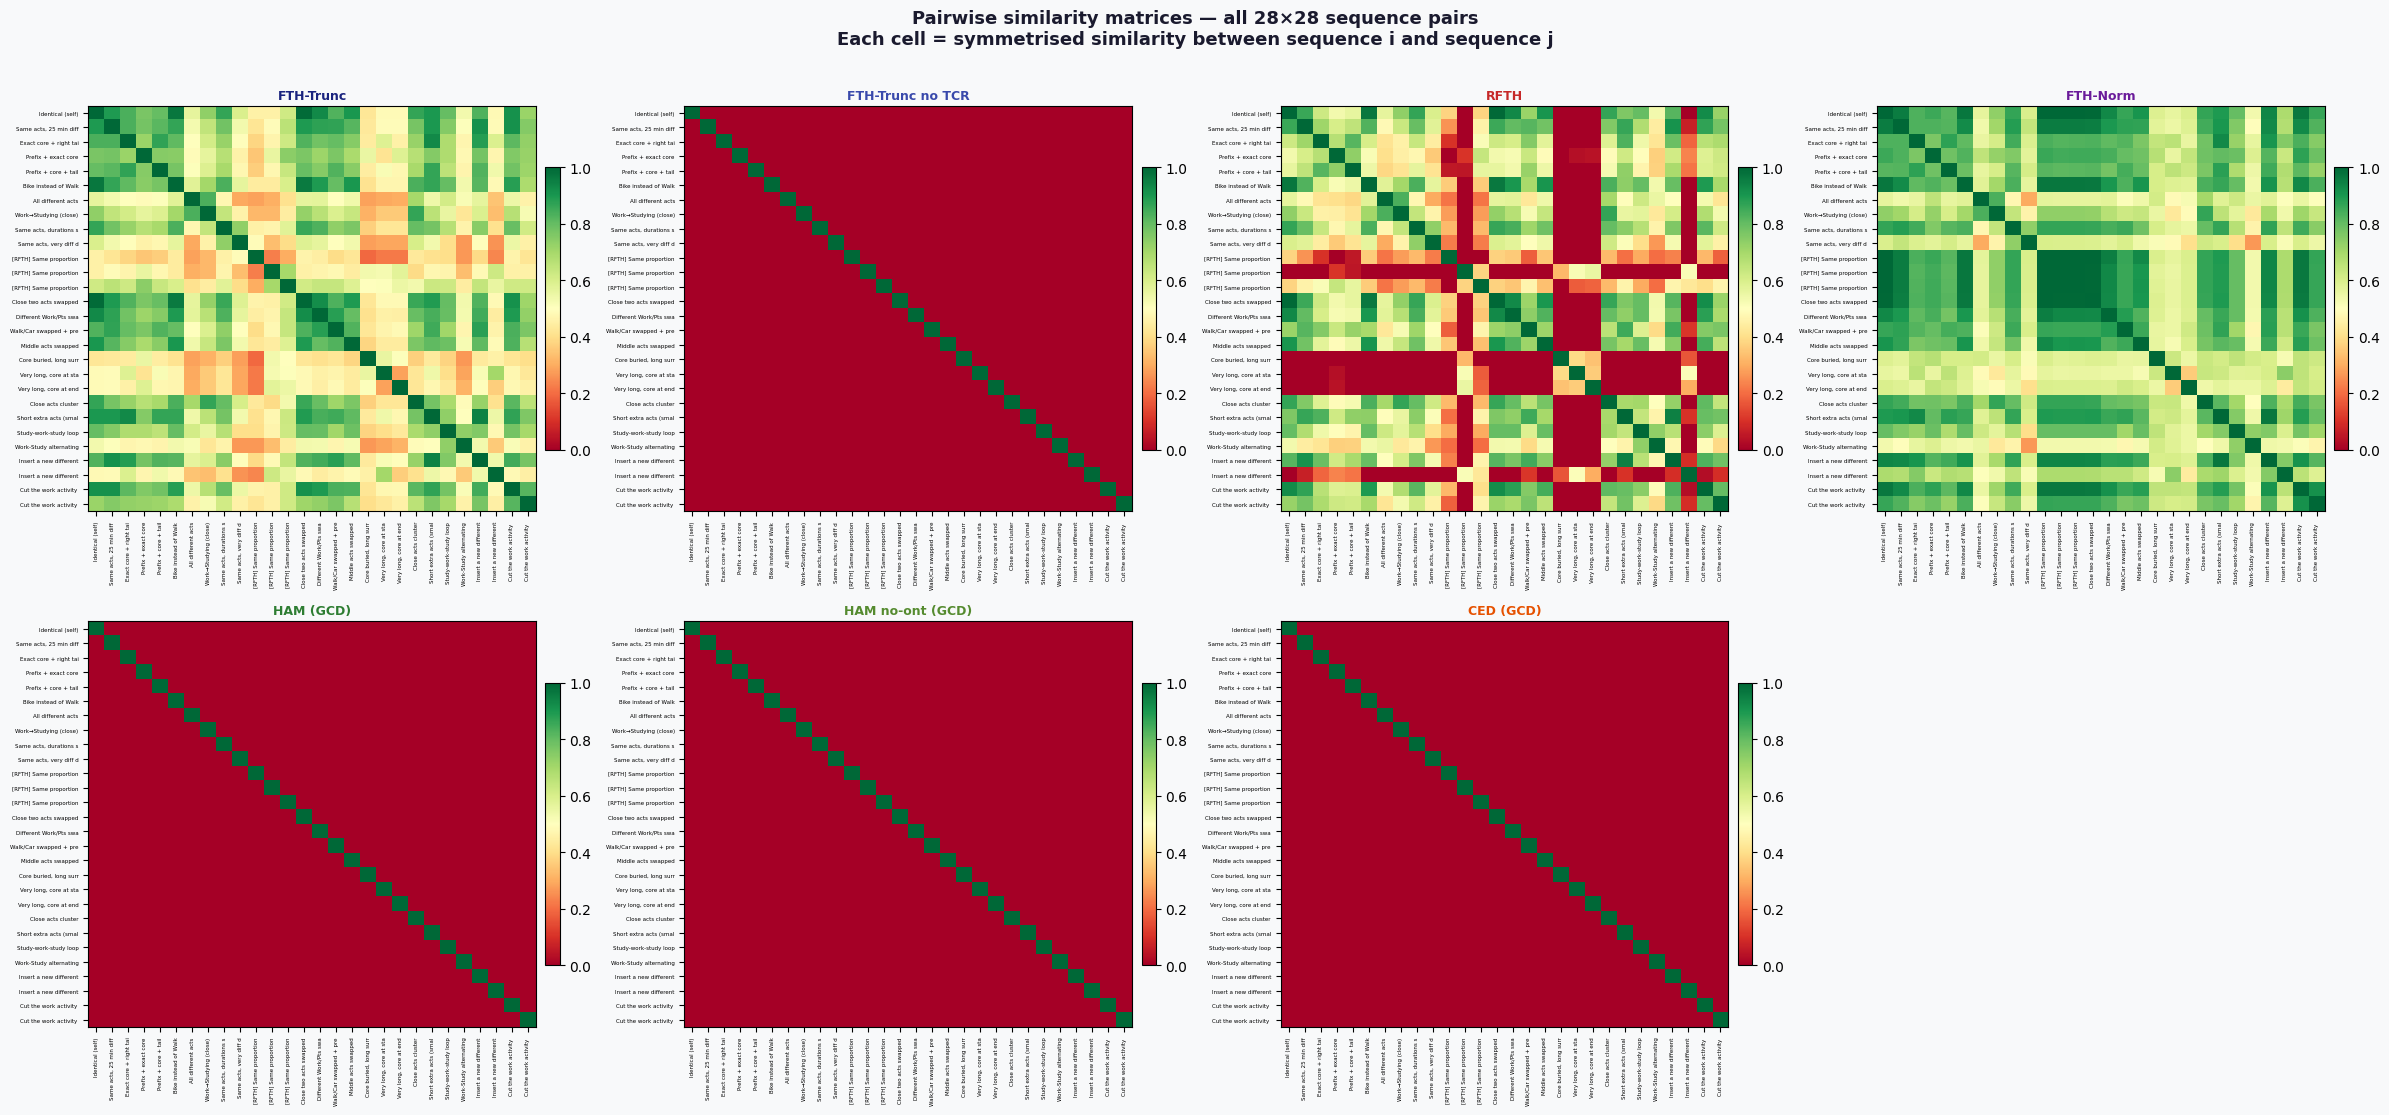

/tmp/ipykernel_4491/2463226872.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set2', N_CLUST)


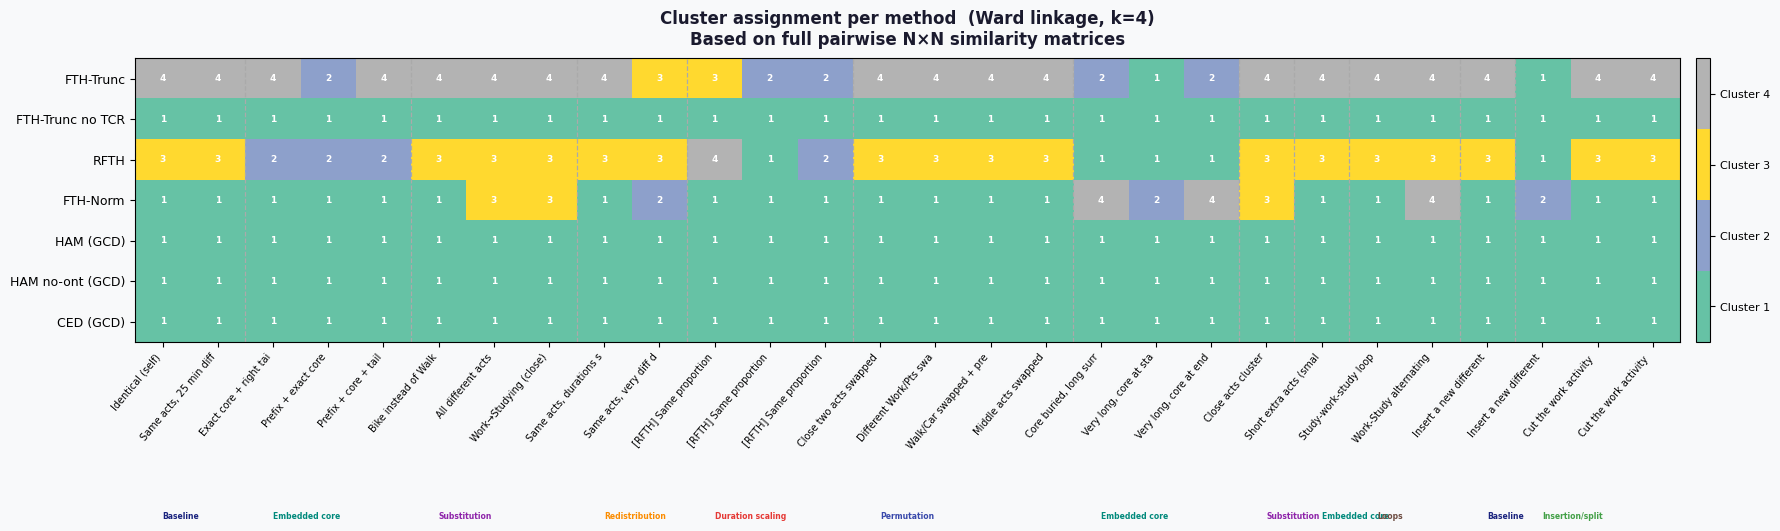

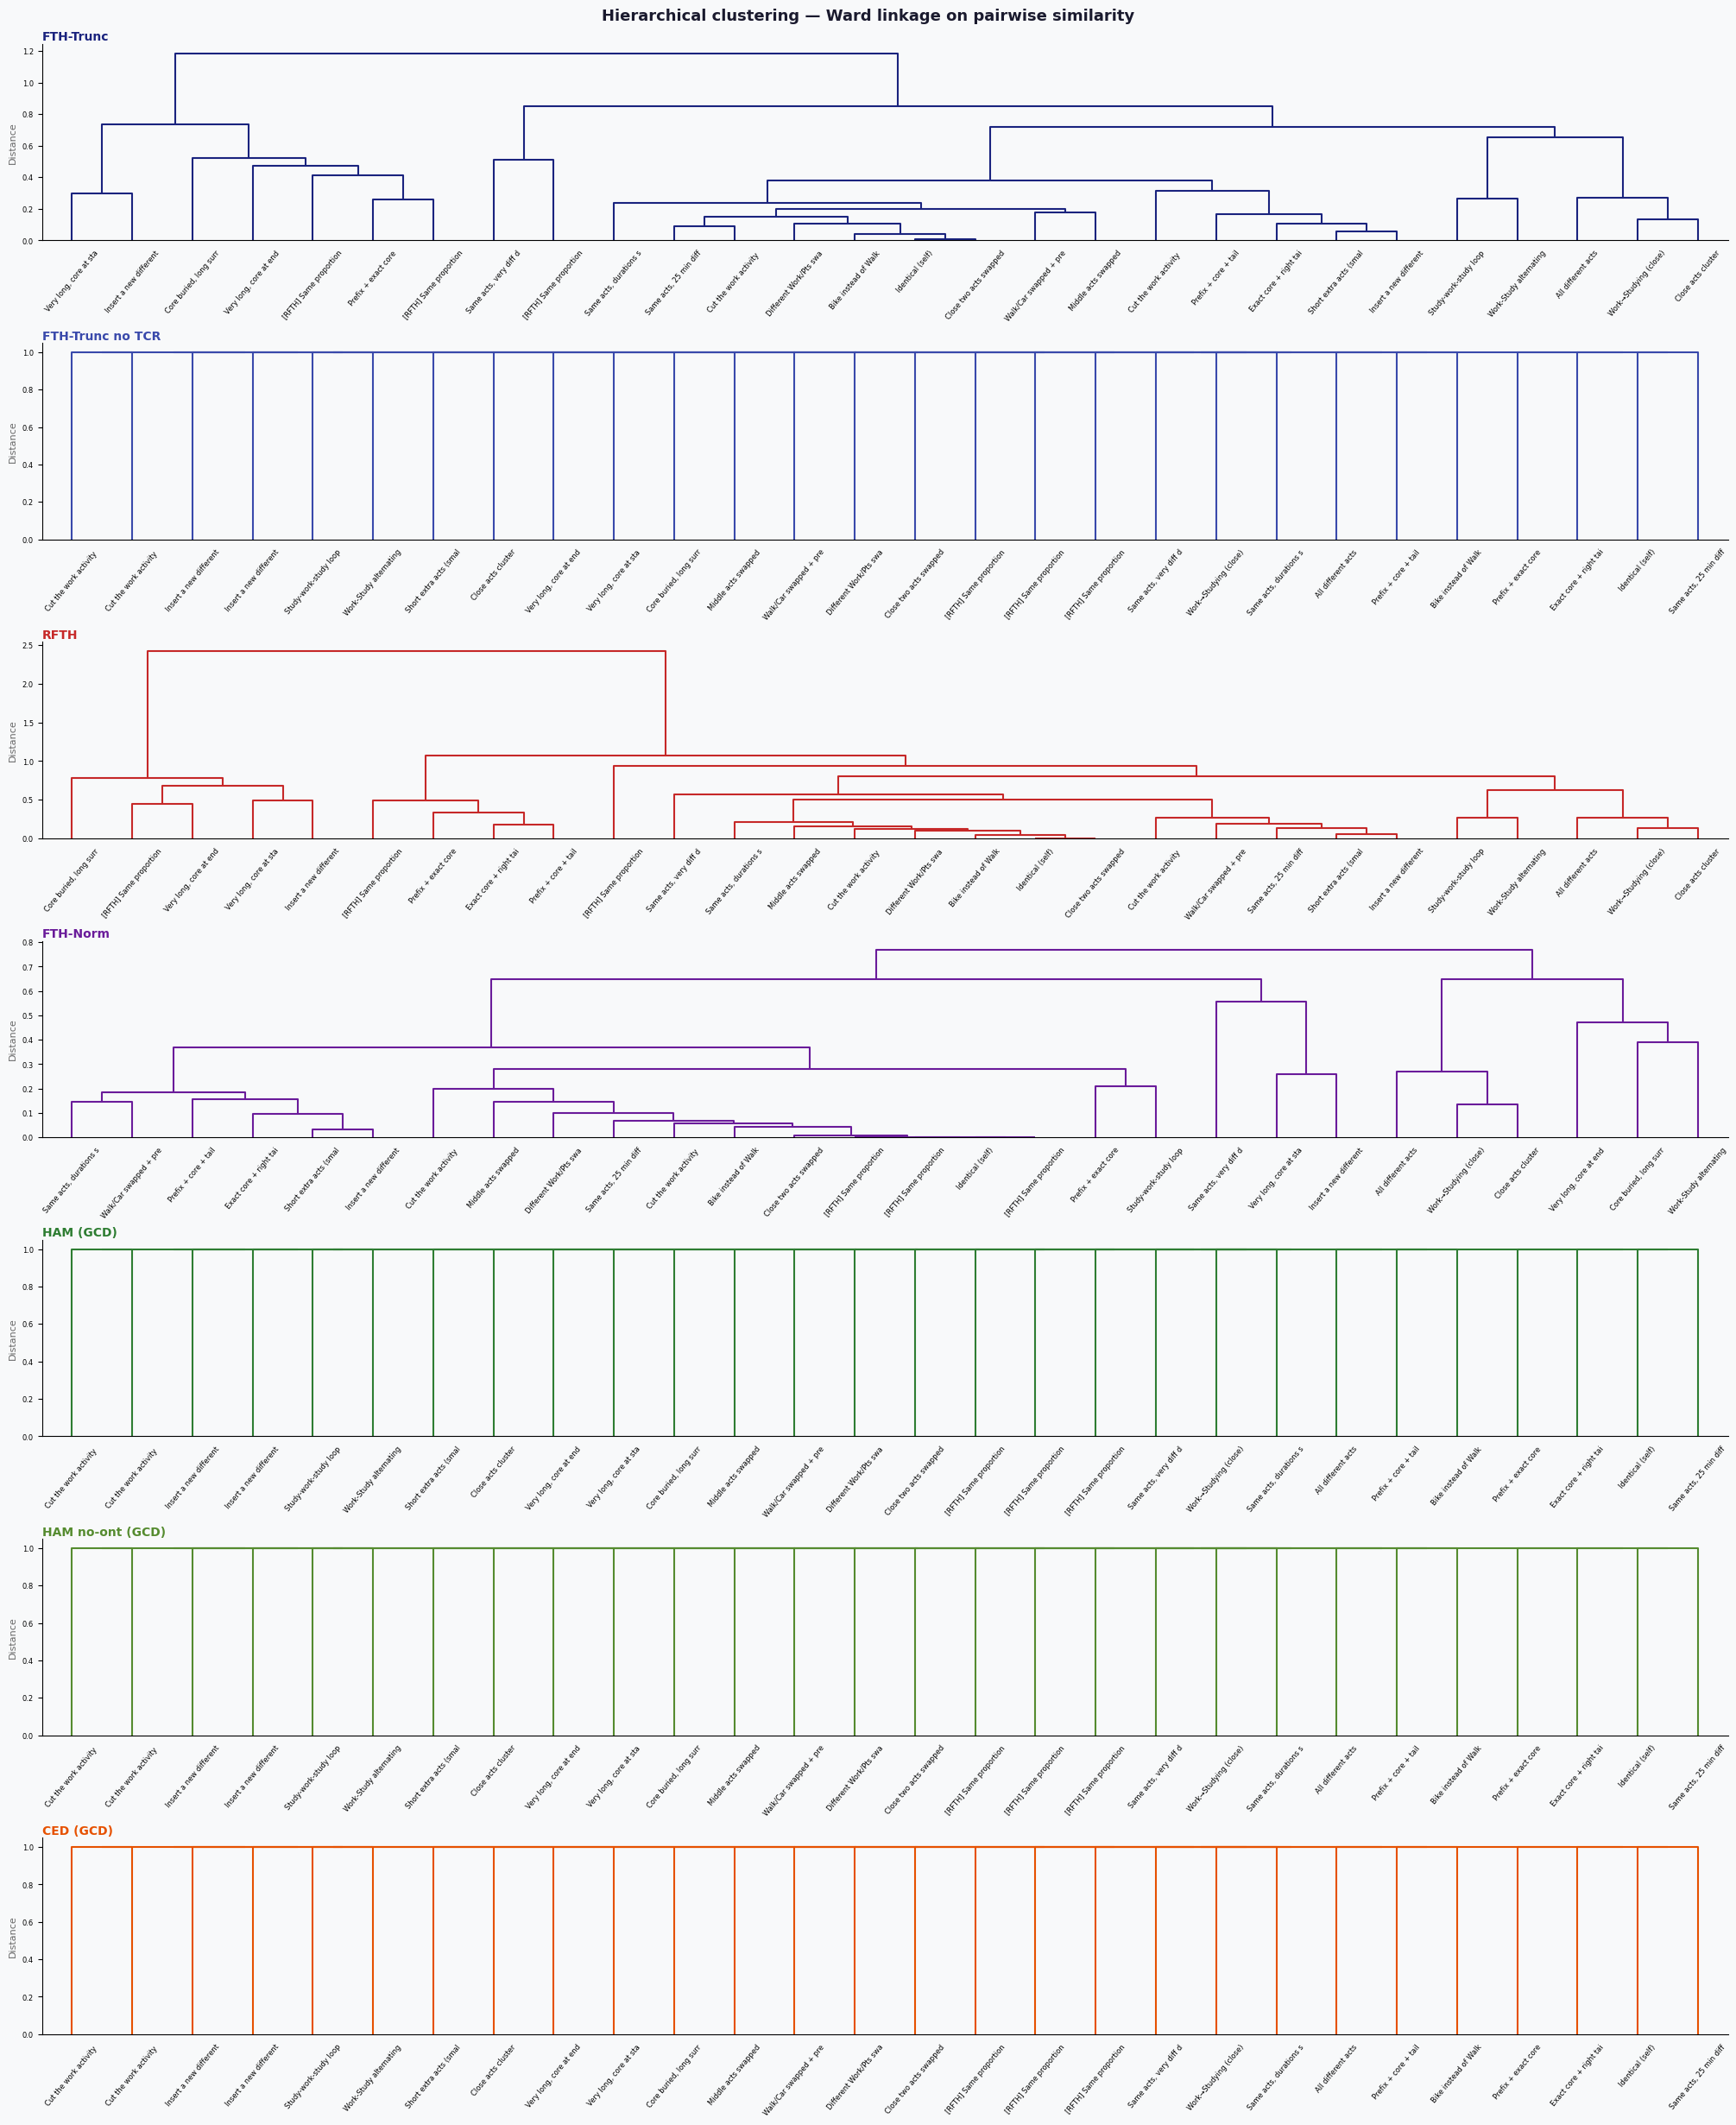

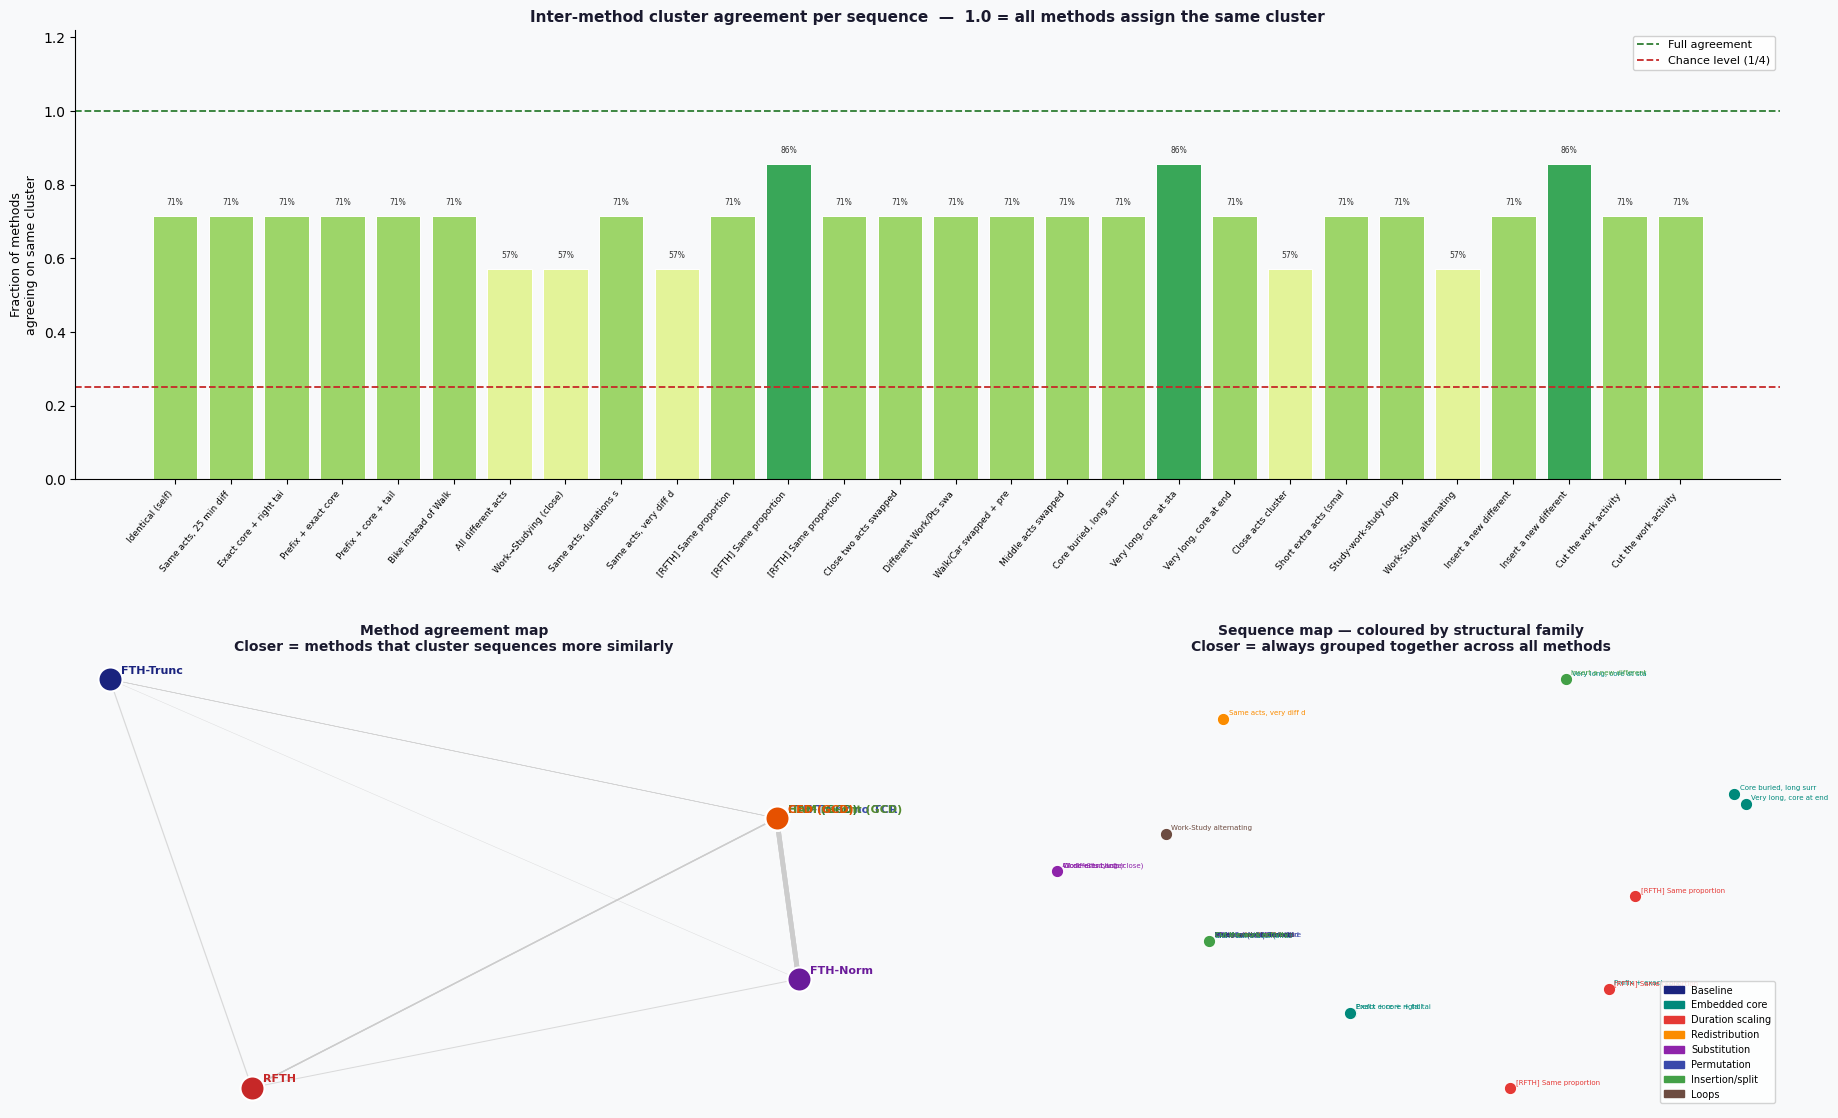

All figures saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.manifold import MDS

# ── Config ────────────────────────────────────────────────────
N_CLUST = 4

PALETTE = {
    'FTH-Trunc':        '#1A237E',
    'FTH-Trunc no TCR': '#3949AB',
    'RFTH':             '#C62828',
    'FTH-Norm':         '#6A1B9A',
    'HAM (GCD)':        '#2E7D32',
    'HAM no-ont (GCD)': '#558B2F',
    'CED (GCD)':        '#E65100',
}

SCENARIO_GROUPS = {
    'Baseline':         [0, 1, 24],
    'Embedded core':    [2, 3, 4, 17, 18, 19, 21],
    'Duration scaling': [10, 11, 12],
    'Redistribution':   [8, 9],
    'Substitution':     [5, 6, 7, 20],
    'Permutation':      [13, 14, 15, 16],
    'Insertion/split':  [25, 26, 27, 28, 29],
    'Loops':            [22, 23],
}

GROUP_COLORS = {
    'Baseline':         '#1A237E',
    'Embedded core':    '#00897B',
    'Duration scaling': '#E53935',
    'Redistribution':   '#FB8C00',
    'Substitution':     '#8E24AA',
    'Permutation':      '#3949AB',
    'Insertion/split':  '#43A047',
    'Loops':            '#6D4C41',
}

def group_color(idx):
    for g, idxs in SCENARIO_GROUPS.items():
        if idx in idxs:
            return GROUP_COLORS[g]
    return '#888888'

point_colors = [group_color(i) for i in range(N)]
N_M          = len(CLUSTER_METHODS)

# ── Run clustering for each method ───────────────────────────
cluster_labels = {}
linkage_data   = {}

for method in CLUSTER_METHODS:
    S  = np.clip(sim_matrices[method], 0, 1)
    D  = 1.0 - S
    np.fill_diagonal(D, 0)
    D  = (D + D.T) / 2
    Z  = linkage(squareform(D), method='ward')
    labs = fcluster(Z, N_CLUST, criterion='maxclust')
    cluster_labels[method] = labs
    linkage_data[method]   = Z

cluster_matrix = np.array(
    [cluster_labels[m] for m in CLUSTER_METHODS])  # (N_M, N)


# ════════════════════════════════════════════════════════════
# FIGURE 1 — N×N pairwise similarity heatmaps
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(24, 11))
fig.patch.set_facecolor('#F8F9FA')
axes_flat = axes.flatten()

for ax_idx, method in enumerate(CLUSTER_METHODS):
    ax = axes_flat[ax_idx]
    S  = sim_matrices[method]
    im = ax.imshow(S, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_title(method, fontsize=9, fontweight='bold',
                 color=PALETTE[method], pad=5)
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=4)
    ax.set_yticklabels(short_labels, fontsize=4)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

axes_flat[-1].set_visible(False)
fig.suptitle(
    f'Pairwise similarity matrices — all {N}×{N} sequence pairs\n'
    'Each cell = symmetrised similarity between sequence i and sequence j',
    fontsize=13, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout()
plt.savefig('fig1_pairwise_heatmaps.pdf', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 2 — Cluster assignment heatmap (method × scenario)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(max(18, N * 0.55), N_M * 0.7 + 2))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

cmap = plt.cm.get_cmap('Set2', N_CLUST)
im   = ax.imshow(cluster_matrix, aspect='auto', cmap=cmap,
                 vmin=0.5, vmax=N_CLUST + 0.5)

ax.set_xticks(range(N))
ax.set_xticklabels(short_labels, rotation=50, ha='right', fontsize=7)
ax.set_yticks(range(N_M))
ax.set_yticklabels(CLUSTER_METHODS, fontsize=9)

for i in range(N_M):
    for j in range(N):
        ax.text(j, i, str(cluster_matrix[i, j]),
                ha='center', va='center',
                fontsize=6.5, color='white', fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cbar.set_ticks(range(1, N_CLUST + 1))
cbar.set_ticklabels([f'Cluster {k}' for k in range(1, N_CLUST + 1)],
                    fontsize=8)

# group separators
prev_g = None
for j in range(N):
    g = next((g for g, idxs in SCENARIO_GROUPS.items()
               if j in idxs), None)
    if g and g != prev_g:
        ax.axvline(j - 0.5, color='#AAAAAA',
                   linewidth=0.9, linestyle='--')
        ax.text(j, -0.6, g, ha='left', va='top',
                fontsize=5.5, color=GROUP_COLORS[g],
                fontweight='bold',
                transform=ax.get_xaxis_transform())
        prev_g = g

ax.set_title(
    f'Cluster assignment per method  (Ward linkage, k={N_CLUST})\n'
    'Based on full pairwise N×N similarity matrices',
    fontsize=12, fontweight='bold', color='#1A1A2E', pad=10)
plt.tight_layout()
plt.savefig('fig2_cluster_heatmap.pdf', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 3 — Dendrograms, one per method
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(N_M, 1,
                          figsize=(20, 3.5 * N_M),
                          constrained_layout=True)
if N_M == 1:
    axes = [axes]
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Hierarchical clustering — Ward linkage on pairwise similarity',
             fontsize=13, fontweight='bold', color='#1A1A2E')

for ax, method in zip(axes, CLUSTER_METHODS):
    ax.set_facecolor('#F8F9FA')
    dendrogram(linkage_data[method],
               labels=short_labels,
               ax=ax,
               leaf_rotation=50,
               leaf_font_size=6,
               color_threshold=0,
               above_threshold_color=PALETTE[method])
    ax.set_title(method, fontsize=10, fontweight='bold',
                 color=PALETTE[method], loc='left', pad=3)
    ax.set_ylabel('Distance', fontsize=8, color='#666')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=6)

plt.savefig('fig3_dendrograms.pdf', dpi=150, bbox_inches='tight')
plt.show()


# ════════════════════════════════════════════════════════════
# FIGURE 4 — Agreement bar + MDS maps
# ════════════════════════════════════════════════════════════

# per-sequence inter-method agreement
agreement_rate = []
for s in range(N):
    labs_s      = [cluster_labels[m][s] for m in CLUSTER_METHODS]
    most_common = max(set(labs_s), key=labs_s.count)
    agreement_rate.append(labs_s.count(most_common) / N_M)

# method × method disagreement
disagree = np.zeros((N_M, N_M))
for i, m1 in enumerate(CLUSTER_METHODS):
    for j, m2 in enumerate(CLUSTER_METHODS):
        disagree[i, j] = np.mean(
            cluster_labels[m1] != cluster_labels[m2])

# sequence × sequence disagreement
cm_T    = cluster_matrix.T   # (N, N_M)
dist_sc = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        dist_sc[i, j] = np.mean(cm_T[i] != cm_T[j])

coords_m = MDS(n_components=2, dissimilarity='precomputed',
               random_state=42,
               normalized_stress='auto').fit_transform(disagree)

coords_s = MDS(n_components=2, dissimilarity='precomputed',
               random_state=42,
               normalized_stress='auto').fit_transform(dist_sc)

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.25)

# ── Top: agreement bars (spans both columns) ─────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#F8F9FA')
bar_colors = [plt.cm.RdYlGn(r) for r in agreement_rate]
bars = ax1.bar(range(N), agreement_rate,
               color=bar_colors, edgecolor='white', linewidth=0.7)
ax1.axhline(1.0, color='#2E7D32', linewidth=1.3,
            linestyle='--', label='Full agreement')
ax1.axhline(1 / N_CLUST, color='#C62828', linewidth=1.3,
            linestyle='--', label=f'Chance level (1/{N_CLUST})')
ax1.set_xticks(range(N))
ax1.set_xticklabels(short_labels, rotation=50,
                    ha='right', fontsize=6.5)
ax1.set_ylim(0, 1.22)
ax1.set_ylabel('Fraction of methods\nagreeing on same cluster',
               fontsize=9)
ax1.set_title(
    'Inter-method cluster agreement per sequence  —  '
    '1.0 = all methods assign the same cluster',
    fontsize=11, fontweight='bold', color='#1A1A2E')
for bar, r in zip(bars, agreement_rate):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.025,
             f'{r:.0%}', ha='center', va='bottom',
             fontsize=5.5, color='#333')
ax1.legend(fontsize=8, framealpha=0.9, edgecolor='#CCC')
ax1.spines[['top', 'right']].set_visible(False)

# ── Bottom-left: method disagreement MDS ─────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#F8F9FA')
ax2.set_title('Method agreement map\n'
              'Closer = methods that cluster sequences more similarly',
              fontsize=10, fontweight='bold', color='#1A1A2E')
for i in range(N_M):
    for j in range(i + 1, N_M):
        lw = max(0.3, (1 - disagree[i, j]) * 5)
        ax2.plot([coords_m[i, 0], coords_m[j, 0]],
                 [coords_m[i, 1], coords_m[j, 1]],
                 color='#CCCCCC', linewidth=lw, alpha=0.7, zorder=1)
for i, method in enumerate(CLUSTER_METHODS):
    ax2.scatter(*coords_m[i], s=300,
                color=PALETTE[method],
                edgecolors='white', linewidths=1.5, zorder=3)
    ax2.annotate(method, coords_m[i],
                 xytext=(8, 4), textcoords='offset points',
                 fontsize=8, color=PALETTE[method], fontweight='bold')
ax2.set_xticks([]); ax2.set_yticks([])
ax2.spines[:].set_visible(False)

# ── Bottom-right: sequence MDS ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#F8F9FA')
ax3.set_title('Sequence map — coloured by structural family\n'
              'Closer = always grouped together across all methods',
              fontsize=10, fontweight='bold', color='#1A1A2E')
for i in range(N):
    ax3.scatter(*coords_s[i], s=80,
                color=point_colors[i],
                edgecolors='white', linewidths=0.8, zorder=3)
    ax3.annotate(short_labels[i], coords_s[i],
                 xytext=(4, 3), textcoords='offset points',
                 fontsize=5, color=point_colors[i])
handles = [mpatches.Patch(color=GROUP_COLORS[g], label=g)
           for g in SCENARIO_GROUPS]
ax3.legend(handles=handles, fontsize=7,
           loc='lower right', framealpha=0.85, edgecolor='#CCC')
ax3.set_xticks([]); ax3.set_yticks([])
ax3.spines[:].set_visible(False)

plt.savefig('fig4_agreement_mds.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("All figures saved.")